# Tuần 05 — Khái quát dữ liệu (1/7): Nền tảng và tính toán xác suất

**UET.MAT1052 — Xác suất thống kê**  
ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

Ở Tuần 04, đường hồi quy tóm tắt những quan sát đã có. Nếu chọn một nhóm sinh viên khác, các con số tóm tắt sẽ thay đổi. Muốn đi từ dữ liệu quan sát tới một phát biểu rộng hơn, ta cần mô tả phần dao động do ngẫu nhiên. Tuần này xây dựng ngôn ngữ và các quy tắc cho việc đó.

Ta bắt đầu bằng hai trò xúc xắc của De Méré, rồi dùng tập hợp, bảng liên hợp và sơ đồ cây để tính xác suất. Các kết luận số trong notebook là kết luận **trong mô hình đã nêu**. Tần suất mô phỏng giúp kiểm tra mô hình; nó không tự xác nhận các giả định ngoài đời.

Sau buổi học, em có thể liệt kê không gian mẫu và biến cố; giải thích và vận dụng ba tiên đề xác suất; tính xác suất có điều kiện bằng cách chọn đúng mẫu số; phân biệt độc lập với xung khắc; dùng quy tắc cộng, nhân, xác suất toàn phần và Bayes; nhận diện hai sai lầm trong lập luận về Sally Clark.

Kiến thức cần nhớ từ Tuần 02–03: số đếm, tỉ lệ, bảng liên hợp và lọc dữ liệu. Chạy lần lượt các ô bằng `Shift + Enter`; trước mỗi mô phỏng hãy dự đoán kết quả, sau đó giải thích sự chênh lệch với tính toán tay. Các bài `W05-*` giữ nguyên mã và mức độ của slide; đáp án nằm trong khối thu gọn.

Những câu hỏi xác suất của slide gồm: khả năng đạt điểm A môn XSTK (32% là con số minh họa có thể ước lượng từ dữ liệu lớp trước, không phải dự báo cho lớp hiện tại); khả năng đội tuyển Việt Nam thắng Thái Lan trong một trận sắp tới (cần thông tin và mô hình dự báo); khả năng gieo hai mặt giống nhau để ra khỏi tù trong Cờ tỷ phú (với hai xúc xắc cân đối độc lập, có 6 trong 36 cặp nên là 1/6); và khả năng ngày mai trời mưa (cần dữ liệu hoặc mô hình thời tiết, không suy ra từ phép đếm xúc xắc).

Một nhà máy kiểm tra ngẫu nhiên vài linh kiện từ một lô lớn. Dù chất lượng lô không đổi, tỉ lệ lỗi trong các mẫu có thể khác nhau. Mô hình xác suất giúp hỏi mức dao động nào có thể do cơ chế lấy mẫu. Những buổi sau mới xây dựng các phương pháp suy luận để đánh giá mức dao động ấy.

**Thực hành Plot:** [hướng dẫn Plotnine](./HUONG_DAN_PLOT.md). Các đoạn “Đọc code vẽ” trong bài giải thích những API được dùng ở từng hình. Ô mô phỏng có thể sinh mẫu mới khi chạy lại; để so sánh hai cách vẽ trên cùng mẫu, khởi động lại kernel và chạy toàn bộ notebook với cùng seed sau mỗi lần sửa.

### Thiết lập tính toán

`rng` là bộ sinh số ngẫu nhiên với seed 42. `n_games` là số ván mô phỏng, mỗi hàng tương ứng một ván. `np`, `pd`, `p9` và `stats` lần lượt gọi NumPy, pandas, Plotnine và các phân phối của SciPy. Mỗi hình được xây từ bảng dữ liệu, `p9.aes(...)` và các lớp `geom_*`, rồi `display(...)` hiển thị ngay dưới ô mã. Dữ liệu của buổi này chủ yếu được liệt kê chính xác hoặc mô phỏng theo cơ chế đã mô tả.


In [21]:
import numpy as np
import pandas as pd
import plotnine as p9
from scipy import stats
from itertools import product
from IPython.display import display

p9.theme_set(p9.theme_minimal(base_size=11))
rng = np.random.default_rng(4200)
n_games = 50_000


## 1. Hai trò chơi của De Méré

Trong trò 1, gieo một xúc xắc cân đối bốn lần, thắng khi có ít nhất một mặt 6. Trong trò 2, gieo hai xúc xắc cân đối 24 lần, thắng khi có ít nhất một cặp $(6,6)$. Các lần gieo độc lập và hai xúc xắc trong mỗi cặp cũng độc lập.

De Méré tính $4(1/6)=24(1/36)=2/3$ và cho rằng hai trò như nhau. Nhưng nhiều mặt 6 có thể xuất hiện trong cùng một ván: cộng xác suất từng lần sẽ đếm lặp ván đó. Trước khi chạy, dự đoán trò nào có xác suất thắng lớn hơn $1/2$.

Ô sau mô phỏng cơ chế gieo. `game1` có shape `(n_games, 4)`; `game2` có shape `(n_games, 24, 2)`. So sánh `== 6` tạo giá trị Boolean. `.any(axis=1)` hỏi có lần thắng nào trong một ván; `.all(axis=2)` yêu cầu cả hai xúc xắc đều là 6. Trung bình của Boolean là tỉ lệ giá trị `True`.

In [22]:
game1 = rng.integers(1, 7, size=(n_games, 4))
game2 = rng.integers(1, 7, size=(n_games, 24, 2))
win1 = (game1 == 6).any(axis=1)
win2 = (game2 == 6).all(axis=2).any(axis=1)
display(pd.DataFrame({"Trò chơi": ["Một mặt 6 / 4 lần", "Một cặp 6-6 / 24 lần"],
                      "Số ván": n_games, "Số thắng": [win1.sum(), win2.sum()],
                      "Tỉ lệ thắng mô phỏng": [win1.mean(), win2.mean()]}))

,Trò chơi,Số ván,Số thắng,Tỉ lệ thắng mô phỏng
0,Một mặt 6 / 4 lần,50000,25822,0.51644
1,Một cặp 6-6 / 24 lần,50000,24546,0.49092


Tỉ lệ thắng của trò 1 ở gần 0,52 và của trò 2 ở gần 0,49. Đây là tỉ lệ của 50.000 ván mô phỏng, chưa phải một chứng minh. Ta sẽ tính xác suất chính xác sau khi học phần bù và quy tắc nhân. Đổi seed hoặc số ván làm tỉ lệ mô phỏng thay đổi; cơ chế của hai trò vẫn như cũ.

### W05-Q01 — Mức độ 1: Sai lầm ban đầu của De Méré

Vì sao không thể cộng trực tiếp $1/6$ bốn lần để tính xác suất “có ít nhất một mặt 6”?

A. Vì xúc xắc không cân đối.  
B. Vì các biến cố “mặt 6 ở lần gieo thứ $i$” có thể cùng xảy ra.  
C. Vì bốn lần gieo không độc lập.  
D. Vì xác suất phải nhỏ hơn $1/2$.

<details><summary>Đáp án và lập luận — W05-Q01</summary><div><p>Đáp án <strong>B</strong>. Các biến cố không xung khắc: một ván có thể xuất hiện mặt 6 ở nhiều lần gieo. Cộng trực tiếp sẽ đếm lặp các kết quả có nhiều mặt 6.</p> </div></details>

## 2. Không gian mẫu và phép toán trên biến cố

Một **phép thử ngẫu nhiên** có thể lặp lại trong điều kiện tương tự, có tập kết quả được mô tả trước, nhưng chưa biết kết quả cụ thể. Chẳng hạn, kiểm tra một linh kiện đạt hay không đạt, gieo xúc xắc hoặc đếm cuộc gọi trong 10 phút.

**Không gian mẫu** $\Omega$ chứa tất cả kết quả có thể của phép thử. Với một xúc xắc, $\Omega=\{1,2,3,4,5,6\}$. Với hai linh kiện, dùng Đ cho đạt và K cho không đạt: $\Omega=\{\mathrm{ĐĐ,ĐK,KĐ,KK}\}$. Với thời gian chờ xe buýt, một mô hình có thể dùng $\Omega=[0,\infty)$. Không gian mẫu có thể hữu hạn, vô hạn đếm được hoặc không đếm được.

Một **biến cố** là tập con của $\Omega$; biến cố xảy ra khi kết quả thuộc tập đó. Với xúc xắc, đặt $A=\{2,4,6\}$ (số chẵn), $B=\{4,5,6\}$ (không nhỏ hơn 4). $A\cup B$ là “ít nhất một biến cố xảy ra”; $A\cap B$ là “cả hai xảy ra”. $\overline A=\Omega\setminus A$ là phần bù, $A\setminus B$ là “thuộc $A$ nhưng không thuộc $B$”.

Nếu $C=\{6\}$, mọi kết quả của $C$ đều thuộc $A$, tức $C\subseteq A$. Bao hàm là quan hệ giữa các tập, không phải giả định độc lập.

Ô sau liệt kê kết quả theo đúng định nghĩa, trước khi gán xác suất. Toán tử `|`, `&` và `-` trên `set` tương ứng hợp, giao và hiệu tập hợp.

In [4]:
omega = set(range(1, 7))
A = {2, 4, 6}
B = {4, 5, 6}
events = {"A hợp B": A | B, "A giao B": A & B,
          "Phần bù A": omega - A, "A trừ B": A - B}
display(pd.DataFrame({"Biến cố": list(events),
                      "Các kết quả": [sorted(event) for event in events.values()]}))
assert {6} <= A
assert A | (omega - A) == omega
assert A & (omega - A) == set()

,Biến cố,Các kết quả
0,A hợp B,"[2, 4, 5, 6]"
1,A giao B,"[4, 6]"
2,Phần bù A,"[1, 3, 5]"
3,A trừ B,[2]


Hợp gồm 2, 4, 5, 6; giao gồm 4, 6; phần bù của A gồm 1, 3, 5; hiệu A trừ B chỉ còn 2. `assert` kiểm tra các đẳng thức; nếu đúng nó không in gì.

### Hình 5.1. Đọc sơ đồ Venn

Hình chữ nhật biểu diễn toàn bộ không gian mẫu. Hai hình tròn là A và B; vùng chồng lên nhau là giao. Bốn miền rời nhau chứa các kết quả khác nhau. Vị trí và diện tích hình tròn trong sơ đồ này chỉ minh họa quan hệ tập hợp, **không biểu diễn xác suất**. Nguồn: tái dựng ý tưởng `Slides/week05.pdf`, trang 21, với tập kết quả ở trang 17.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_polygon` ghép các đỉnh thành miền kín; kiểm tra biến `group` khi có nhiều miền. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

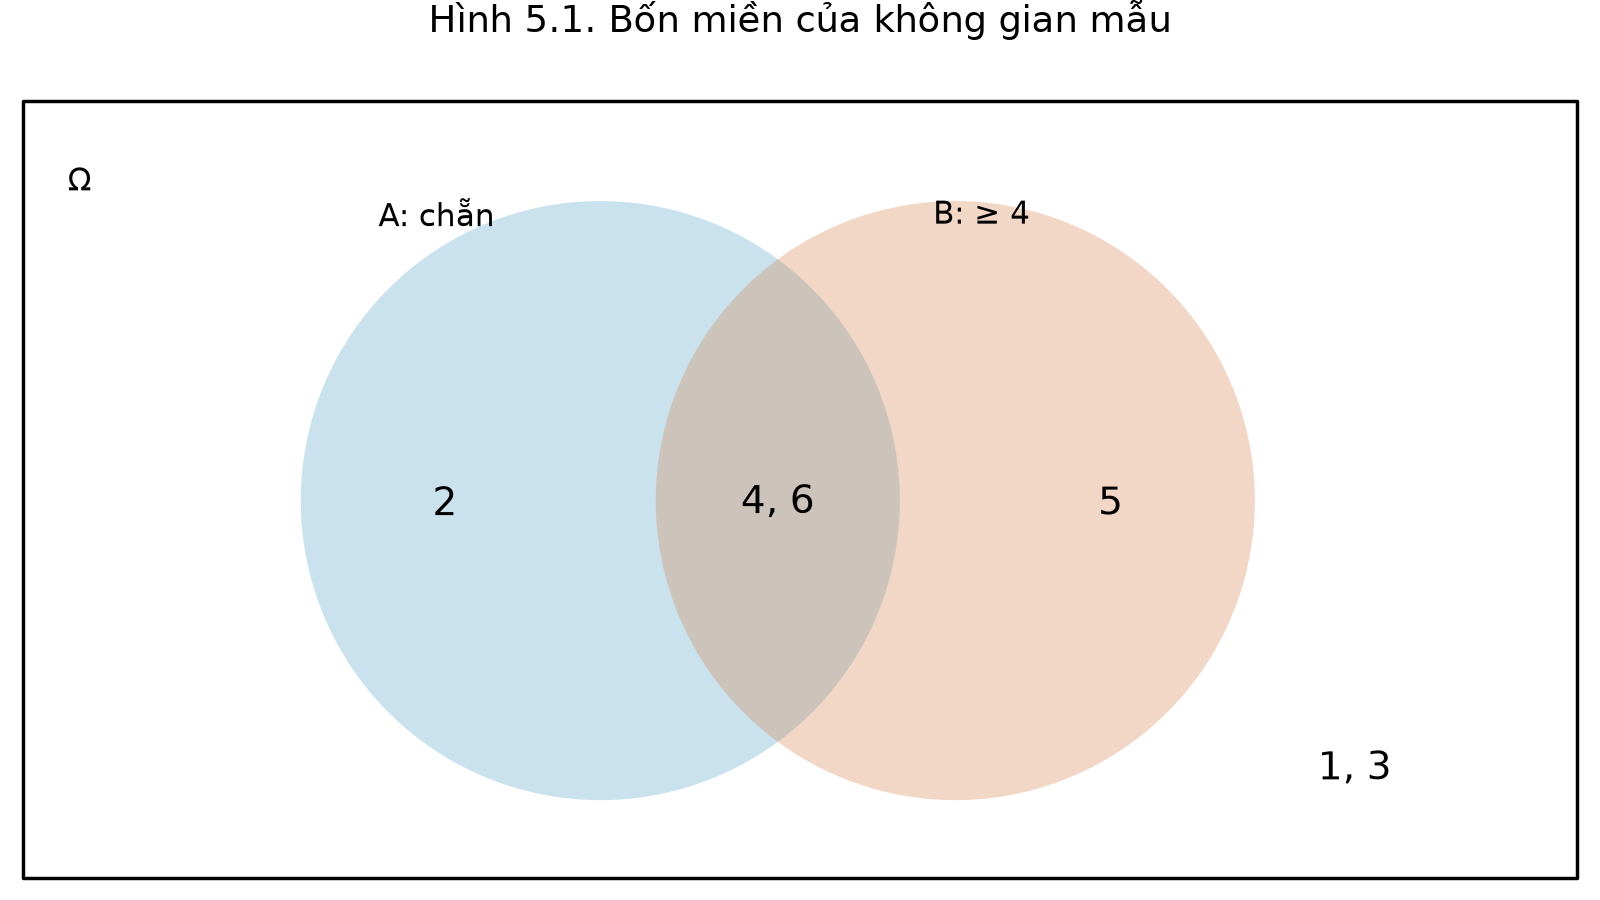

In [5]:
# Mỗi dòng là một đỉnh; group nối các đỉnh thành đúng một miền.
theta = np.linspace(0, 2*np.pi, 241)
circles = pd.concat([
    pd.DataFrame({"x": cx + 1.35*np.cos(theta),
                  "y": 1.7 + 1.35*np.sin(theta), "Biến cố": name})
    for cx, name in [(2.6, "A"), (4.2, "B")]
], ignore_index=True)
frame = pd.DataFrame({"x": [0, 7, 7, 0], "y": [0, 0, 3.5, 3.5]})
region_labels = pd.DataFrame({"x": [1.9, 3.4, 4.9, 6.0], "y": [1.7, 1.7, 1.7, 0.5],
                              "label": ["2", "4, 6", "5", "1, 3"]})
set_labels = pd.DataFrame({"x": [1.6, 4.1, 0.2], "y": [3.0, 3.0, 3.15],
                           "label": ["A: chẵn", "B: ≥ 4", "Ω"]})
venn_plot = (
    p9.ggplot()
    + p9.geom_polygon(frame, p9.aes("x", "y"), fill=None, color="black", size=0.7)
    + p9.geom_polygon(circles, p9.aes("x", "y", group="Biến cố", fill="Biến cố"),
                      alpha=0.30, color=None)
    + p9.scale_fill_manual(values={"A": "#4C9FC7", "B": "#D57B43"})
    + p9.geom_text(region_labels, p9.aes("x", "y", label="label"), size=14)
    + p9.geom_text(set_labels, p9.aes("x", "y", label="label"), ha="left", size=11)
    + p9.coord_fixed(xlim=(-0.1, 7.1), ylim=(-0.1, 3.7), expand=False)
    + p9.labs(title="Hình 5.1. Bốn miền của không gian mẫu")
    + p9.theme_void()
    + p9.theme(figure_size=(8, 4.5), legend_position="none")
)
display(venn_plot)


### W05-BT01: Một phép thử có hai nhánh

Tung đồng xu cân đối. Nếu lần đầu ngửa H thì tung thêm một lần; nếu sấp T thì gieo một xúc xắc cân đối. Lần thứ hai độc lập với lần đầu trong mỗi nhánh. Ghi kết quả theo thứ tự.

1. Liệt kê không gian mẫu và các nhánh.
2. Các kết quả cuối có đồng khả năng không?

<details><summary>Đáp án và lập luận — W05-BT01</summary><div><p>$\Omega=\{HH,HT,T1,T2,T3,T4,T5,T6\}$. Nhánh H dẫn tới HH hoặc HT, nhánh T dẫn tới T1–T6. $P(HH)=P(HT)=1/4$; $P(Tj)=(1/2)(1/6)=1/12$ với $j=1,\ldots,6$. Tám kết quả <strong>không đồng khả năng</strong>; không được dùng $1/8$ cho từng kết quả.</p> </div></details>

Hai biến cố **xung khắc** nếu $A\cap B=\varnothing$. Hai biến cố **đối nhau** nếu còn phủ hết không gian mẫu: $B=A^c$. Hai mức A và B của một linh kiện có thể xung khắc mà chưa đối nhau, vì linh kiện còn mức C hoặc bị loại.

Hai định luật **De Morgan** giúp dịch câu phủ định:

$$
\overline{A\cup B}=\overline{A}\cap \overline{B},\qquad \overline{A\cap B}=\overline{A}\cup \overline{B}.
$$

“Không biến cố nào xảy ra” yêu cầu cả hai không xảy ra. “Không đồng thời xảy ra cả hai” vẫn cho phép chỉ một biến cố xảy ra. Hai câu có tập kết quả khác nhau.

### W05-Q02 — Mức độ 1: Xung khắc hay đối nhau?

Một vé hỗ trợ nhận đúng một mức: thấp, trung bình, cao, khẩn cấp. A: vé mức thấp; B: vé mức cao.

A. Độc lập và đối nhau.  
B. Xung khắc nhưng không đối nhau.  
C. Đối nhau nhưng không xung khắc.  
D. Không xung khắc.

<details><summary>Đáp án và lập luận — W05-Q02</summary><div><p>Đáp án <strong>B</strong>. Vé không thể vừa thấp vừa cao. Nhưng không thấp còn có thể là trung bình hoặc khẩn cấp, nên B không phải phần bù của A.</p> </div></details>

### W05-EX01 — Mức độ 2: Hai máy chủ

A: máy chủ 1 gặp sự cố trong ngày; B: máy chủ 2 gặp sự cố. Biểu diễn: (1) ít nhất một máy chủ gặp sự cố; (2) cả hai hoạt động bình thường; (3) không đồng thời xảy ra hai sự cố; (4) chỉ máy chủ 1 gặp sự cố.

<details><summary>Đáp án và lập luận — W05-EX01</summary><div><ol> <li>$A\cup B$.  2. $A^c\cap B^c=(A\cup B)^c$.  3. $(A\cap B)^c=A^c\cup B^c$.  4. $A\setminus B=A\cap B^c$. Câu 2 và 3 khác nhau: câu 3 còn cho phép đúng một máy gặp sự cố.</li> </ol> </div></details>

### W05-BT02: Ba nhà máy

$A_i$: nhà máy tại địa điểm $i$ hoàn thành đúng hạn, $i=1,2,3$. Biểu diễn (1) ít nhất một; (2) cả ba; (3) chỉ nhà máy 1; (4) đúng một nhà máy hoàn thành đúng hạn.

<details><summary>Đáp án và lập luận — W05-BT02</summary><div><ol> <li>$A_1\cup A_2\cup A_3$.</li> <li>$A_1\cap A_2\cap A_3$.</li> <li>$A_1\cap A_2^c\cap A_3^c$.</li> <li>$(A_1\cap A_2^c\cap A_3^c)\cup(A_1^c\cap A_2\cap A_3^c)\cup(A_1^c\cap A_2^c\cap A_3)$.</li> </ol> <p>Ba trường hợp ở câu 4 đôi một xung khắc. Biểu diễn này không cần giả định các nhà máy độc lập.</p> </div></details>

## 3. Từ tập kết quả đến xác suất

Xác suất $P(A)$ gán cho biến cố $A$ một con số đo khả năng xảy ra trong mô hình. Các số phải thỏa ba **tiên đề**:

$$
P(A)\ge0,\qquad P(\Omega)=1,\qquad
P\left(\bigcup_i A_i\right)=\sum_i P(A_i)
\quad\text{khi các }A_i\text{ đôi một xung khắc}.
$$

Tiên đề cuối áp dụng cho một dãy hữu hạn hoặc đếm được các biến cố. Từ đó suy ra $P(\varnothing)=0$, $0\le P(A)\le1$, $P(A^c)=1-P(A)$; nếu $A\subseteq B$ thì $P(A)\le P(B)$; và $P(A\setminus B)=P(A)-P(A\cap B)$.

Trong không gian mẫu **hữu hạn, đồng khả năng**, ta có $P(A)=|A|/|\Omega|$. $|A|$ là số kết quả thuận lợi, $|\Omega|$ là tổng số kết quả. Với xúc xắc cân đối, $P(A)=3/6$ cho số chẵn và $P(A\cap B)=2/6$ cho số chẵn không nhỏ hơn 4. W05-BT01 cho thấy vì sao phải kiểm tra điều kiện đồng khả năng trước khi đếm.

Một đồng xu cân đối có xác suất ngửa $1/2$; đồng xu thiên vị không nhất thiết như vậy. Chọn ngẫu nhiên một thẻ từ hộp thì các **thẻ** đồng khả năng, nhưng giá trị hoặc màu trên các thẻ không nhất thiết đồng khả năng. Ví dụ hộp $[0,0,1,2]$ có $P(0)=1/2$, $P(1)=P(2)=1/4$. Roulette kiểu Mỹ có 18 ô đỏ, 18 đen và hai xanh: $P(\text{đỏ})=18/38$, không phải $1/2$. Các ví dụ bổ sung này nối với STAT20 VN §3.1.5 và chuẩn bị cho Tuần 06.

Nếu phép thử lặp độc lập trong cùng điều kiện, tần suất tương đối có xu hướng ổn định quanh xác suất khi số lần lặp tăng. Một đoạn dao động lên không buộc đoạn tiếp theo phải đi xuống: sự hội tụ không đồng nghĩa đường đi đơn điệu.

In [6]:
event_probabilities = pd.Series({name: len(event) / len(omega)
                                for name, event in events.items()}, name="Xác suất")
display(event_probabilities.to_frame())
ticket_values = np.array([0, 0, 1, 2])
display(pd.Series(ticket_values).value_counts(normalize=True).sort_index().rename("P(giá trị)").to_frame())

,Xác suất
A hợp B,0.666667
A giao B,0.333333
Phần bù A,0.500000
A trừ B,0.166667


,P(giá trị)
0,0.50
1,0.25
2,0.25


### Quy tắc cộng tổng quát

Khi cộng $P(A)$ và $P(B)$, phần giao bị đếm hai lần, nên phải trừ một lần:

$$P(A\cup B)=P(A)+P(B)-P(A\cap B).$$

Chỉ khi xung khắc, phần giao có xác suất 0 và ta mới cộng trực tiếp. Với ba biến cố, áp dụng cùng cách sửa đếm lặp:

$$P(A\cup B\cup C)=P(A)+P(B)+P(C)-P(A\cap B)-P(A\cap C)-P(B\cap C)+P(A\cap B\cap C).$$

Công thức ba biến cố là phần giải thích bổ sung của nguyên lý bao hàm–loại trừ trong STAT20 VN §3.3.9.

Trong ví dụ của slide, một khảo sát gồm 137 hộ. Các ô trong bảng sau là **số đếm của bài toán**, không phải dữ liệu do notebook thu thập. Chọn đều một trong 137 hộ; I là dùng Internet, T là dùng truyền hình. Ta có $P(I)=86/137$, $P(T)=107/137$, $P(I\cap T)=69/137$. Vì vậy $P(I\cup T)=(86+107-69)/137=124/137\approx0{,}9051$. Cũng có thể lấy $1-13/137$.

In [7]:
households = pd.DataFrame([[13, 38], [17, 69]],
                          index=["Không Internet", "Có Internet"],
                          columns=["Không truyền hình", "Có truyền hình"])
display(households)
total = households.to_numpy().sum()
p_internet = households.loc["Có Internet"].sum() / total
p_tv = households["Có truyền hình"].sum() / total
p_both = households.loc["Có Internet", "Có truyền hình"] / total
p_either = p_internet + p_tv - p_both
print(f"P(I hoặc T) = {p_either:.6f}; kiểm tra bằng phần bù = {1 - 13 / total:.6f}")

,Không truyền hình,Có truyền hình
Không Internet,13,38
Có Internet,17,69


P(I hoặc T) = 0.905109; kiểm tra bằng phần bù = 0.905109


## 4. Biết thêm thông tin: mẫu số nào còn phù hợp?

Khi biết hộ có Internet, ta chỉ xét 86 hộ của hàng đó. Trong 86 hộ, 69 hộ dùng truyền hình, nên $P(T\mid I)=69/86$. Khi biết hộ có truyền hình, mẫu số trở thành 107. **Xác suất có điều kiện** chính thức là

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)},\qquad P(B)>0.$$

$B$ là thông tin đã biết và quyết định tập tham chiếu. Tử số giữ các kết quả vừa thỏa $A$ vừa thỏa $B$. Nếu $P(B)=0$, công thức tỉ số này không xác định.

### W05-EX02 — Mức độ 2: Hai chiều điều kiện

Từ bảng 137 hộ, 86 hộ có Internet, 107 hộ có truyền hình và 69 hộ có cả hai. Tính $P(T\mid I)$ và $P(I\mid T)$. Chúng có bằng nhau không?

<details><summary>Đáp án và lập luận — W05-EX02</summary><div><p>$P(T\mid I)=69/86\approx0{,}8023$; $P(I\mid T)=69/107\approx0{,}6449$. Cùng tử số 69 nhưng khác mẫu số. Hai xác suất trả lời hai câu hỏi khác nhau.</p> </div></details>

Ô sau dựng đầy đủ 36 cặp xúc xắc có thứ tự bằng `product`. Mỗi hàng là một kết quả đồng khả năng. Các cột Boolean là biến cố; lọc `different` thu hẹp tập tham chiếu. Hãy đếm tay số hàng còn lại và số hàng có ít nhất một mặt 6 trước khi chạy.

In [8]:
dice_pairs = pd.DataFrame(list(product(range(1, 7), repeat=2)), columns=["die1", "die2"])
dice_pairs["different"] = dice_pairs["die1"] != dice_pairs["die2"]
dice_pairs["at_least_one_six"] = (dice_pairs["die1"] == 6) | (dice_pairs["die2"] == 6)
conditional_pairs = dice_pairs.loc[dice_pairs["different"]]
print("Kết quả có hai mặt khác nhau:", len(conditional_pairs))
print("Trong đó có ít nhất một 6:", conditional_pairs["at_least_one_six"].sum())
print("P(ít nhất một 6 | khác nhau) =", conditional_pairs["at_least_one_six"].mean())

Kết quả có hai mặt khác nhau: 30
Trong đó có ít nhất một 6: 10
P(ít nhất một 6 | khác nhau) = 0.3333333333333333


Còn 30 kết quả; 10 kết quả thỏa biến cố cần tính, nên xác suất có điều kiện là 1/3. Cặp (6,6) có mặt 6 nhưng đã bị loại khỏi tập tham chiếu. Đếm toàn bộ 11 kết quả có mặt 6 rồi chia cho 30 sẽ dùng sai tử số.

### W05-BT04: Hai xúc xắc có số chấm khác nhau

Gieo hai xúc xắc cân đối độc lập, phân biệt xúc xắc 1 và 2. Biết hai số chấm khác nhau, tính xác suất ít nhất một mặt 6. Gọi A là có ít nhất một 6, B là hai số khác nhau; xác định B và A giao B trước khi tính.

<details><summary>Đáp án và lập luận — W05-BT04</summary><div><p>B có $36-6=30$ cặp. $A\cap B=\{(6,j):j=1,\ldots,5\}\cup\{(i,6):i=1,\ldots,5\}$ có 10 cặp. $P(A\mid B)=(10/36)/(30/36)=1/3$. $(6,6)$ không thuộc B.</p> </div></details>

### Quy tắc nhân và cơ chế lấy mẫu

Nhân xác suất của một bước với xác suất bước tiếp theo **trong điều kiện bước trước đã xảy ra**:

$$P(A\cap B)=P(A)P(B\mid A)=P(B)P(A\mid B).$$

Với ba biến cố: $P(A\cap B\cap C)=P(A)P(B\mid A)P(C\mid A\cap B)$ khi các điều kiện dùng trong tỉ số có xác suất dương. Điều kiện ở bước thứ ba chứa cả hai bước trước.

Túi có 3 quân xanh và 7 quân khác. Rút hai quân không hoàn lại. Nếu lần đầu đã xanh, còn 2 xanh trong 9 quân, nên xác suất hai xanh là $(3/10)(2/9)=1/15$. Dùng $(3/10)^2$ sẽ bỏ qua việc túi đã thay đổi.

Ô sau so sánh lấy có và không hoàn lại bằng cách liệt kê chỉ số quân 0–9; quân 0, 1, 2 là xanh. Đây là tính toán **chính xác**, không phải mô phỏng.

In [9]:
ordered_draws = np.array(list(product(range(10), repeat=2)))
blue_both = (ordered_draws < 3).all(axis=1)
no_replacement = ordered_draws[:, 0] != ordered_draws[:, 1]
print("Có hoàn lại:", blue_both.mean(), "= (3/10)^2")
print("Không hoàn lại:", blue_both[no_replacement].mean(), "= (3/10)(2/9)")

Có hoàn lại: 0.09 = (3/10)^2
Không hoàn lại: 0.06666666666666667 = (3/10)(2/9)


### Độc lập là một đẳng thức về xác suất

$A$ và $B$ **độc lập** khi $P(A\cap B)=P(A)P(B)$. Nếu $P(B)>0$, điều đó tương đương $P(A\mid B)=P(A)$; nếu $P(A)>0$, tương đương $P(B\mid A)=P(B)$. Không cần điều kiện dương để dùng định nghĩa bằng tích.

Các lần tung xu thường được mô hình hóa độc lập. Lấy ngẫu nhiên có hoàn lại và trộn lại theo cùng cơ chế cũng thường tạo những lần lấy độc lập. Lấy không hoàn lại thường làm các lần phụ thuộc. Cơ chế lấy mẫu cần được nêu; chỉ nhìn hai tên biến không đủ kết luận độc lập.

Trong bảng lớp học dưới đây, chọn đều một trong 126 sinh viên. A: có phụ đạo, B: nhóm 1. $P(A)=42/126=1/3$ và $P(A\mid B)=18/54=1/3$. Hai thuộc tính **độc lập trong phân phối hữu hạn của bảng này**. Chưa đủ cơ sở khẳng định độc lập trong mọi lớp hoặc kết luận phụ đạo không có tác động nhân quả.

In [10]:
class_table = pd.DataFrame([[36, 18], [48, 24]], index=["Nhóm 1", "Nhóm 2"],
                           columns=["Không phụ đạo", "Có phụ đạo"])
display(class_table)
print("P(phụ đạo):", class_table["Có phụ đạo"].sum() / class_table.to_numpy().sum())
print("P(phụ đạo | nhóm):")
display(class_table["Có phụ đạo"] / class_table.sum(axis=1))

,Không phụ đạo,Có phụ đạo
Nhóm 1,36,18
Nhóm 2,48,24


P(phụ đạo): 0.3333333333333333
P(phụ đạo | nhóm):


Nhóm 1    0.333333
Nhóm 2    0.333333
dtype: float64

### W05-BT05: Hai túi bi

Túi 1 có 3 trắng, 7 đỏ, 15 xanh. Túi 2 có 10 trắng, 6 đỏ, 9 xanh. Lấy đều một viên mỗi túi, hai lần lấy độc lập. Tính xác suất cùng màu. Nêu khi nào dùng quy tắc nhân, khi nào dùng quy tắc cộng.

<details><summary>Đáp án và lập luận — W05-BT05</summary><div><p>Ba trường hợp cùng màu là trắng–trắng, đỏ–đỏ, xanh–xanh, đôi một xung khắc. Nhân trong mỗi trường hợp nhờ hai lần lấy độc lập; cộng ba trường hợp: $(3\cdot10+7\cdot6+15\cdot9)/25^2=207/625=0{,}3312$.</p> </div></details>

### W05-EX03 — Mức độ 2: Tổng bằng 6 và mặt thứ nhất bằng 4

Gieo hai xúc xắc cân đối. E: tổng bằng 6; F: xúc xắc thứ nhất bằng 4. Biết $P(E)=5/36$, tính $P(E\mid F)$ và kiểm tra độc lập.

<details><summary>Đáp án và lập luận — W05-EX03</summary><div><p>Trong 6 cặp có xúc xắc 1 bằng 4, chỉ cặp $(4,2)$ có tổng 6: $P(E\mid F)=1/6\ne5/36=P(E)$. Hai biến cố phụ thuộc.</p> </div></details>

### Sally Clark: hai câu hỏi cần tách riêng

Slide kể trường hợp Sally Clark bị kết tội năm 1999 sau khi hai con nhỏ qua đời. Một nhân chứng lấy con số $1/8543$ cho một trường hợp đột tử ở trẻ sơ sinh, rồi bình phương để được xấp xỉ “1 trên 73 triệu”. **Con số này được dẫn lại để phân tích sai lầm của lập luận trong nguồn**, không được dùng như ước lượng y khoa hay kết luận về trường hợp cụ thể.

Sai lầm thứ nhất là giả định độc lập. Với $S_1,S_2$ là hai trường hợp đang xét, công thức đúng là $P(S_1\cap S_2)=P(S_1)P(S_2\mid S_1)$. Yếu tố gia đình hoặc sinh học chung có thể làm xác suất có điều kiện khác xác suất biên.

Sai lầm thứ hai là đảo chiều: $P(\text{bằng chứng}\mid\text{vô tội})$ khác $P(\text{vô tội}\mid\text{bằng chứng})$. Một bằng chứng hiếm dưới giả thuyết vô tội không tự xác định xác suất vô tội khi đã thấy bằng chứng. Cần xét giả thuyết cạnh tranh, xác suất ban đầu và toàn bộ bằng chứng.

Ô sau là **phân tích độ nhạy bổ sung bằng tham số giả định**, không mô phỏng hay suy luận về hồ sơ pháp lý. `multipliers` thay đổi nguy cơ có điều kiện so với nguy cơ biên; hỏi vì sao cùng một số biên lại cho nhiều xác suất đồng thời khác nhau.

In [11]:
p_reference = 1 / 8543
multipliers = np.array([1, 2, 5, 10])
p_second_given_first = multipliers * p_reference
display(pd.DataFrame({"Hệ số giả định": multipliers,
                      "P(S2 | S1) giả định": p_second_given_first,
                      "P(S1 và S2)": p_reference * p_second_given_first}))

,Hệ số giả định,P(S2 | S1) giả định,P(S1 và S2)
0,1,0.000117,1.370185e-08
1,2,0.000234,2.740370e-08
2,5,0.000585,6.850925e-08
3,10,0.001171,1.370185e-07


## 5. Xác suất toàn phần và định lý Bayes

Một **phân hoạch** $A_1,\ldots,A_k$ gồm các biến cố đôi một xung khắc và phủ toàn bộ $\Omega$. Một sản phẩm thuộc đúng một dây chuyền, hoặc một thư thuộc đúng một tài khoản, tạo ra các nhóm như vậy.

Để tính khả năng kết quả $B$ xảy ra, cộng khả năng đi tới $B$ qua mỗi nhóm:

$$P(B)=\sum_{i=1}^{k}P(B\mid A_i)P(A_i).$$

$P(A_i)$ là trọng số của nhóm $i$; $P(B\mid A_i)$ là xác suất kết quả trong nhóm đó. Với nhóm có xác suất 0, có thể bỏ nhóm khỏi tổng. Một nhà máy có dây chuyền A tạo 60% sản lượng với 2% lỗi và B tạo 40% với 5% lỗi. Xác suất lỗi là $0{,}6(0{,}02)+0{,}4(0{,}05)=0{,}032$.

Biết một sản phẩm đã lỗi, ta muốn đổi chiều để xác định nguồn. **Định lý Bayes** chia phần xác suất “nguồn $A_j$ và kết quả $B$” cho toàn bộ xác suất $B$:

$$P(A_j\mid B)=\frac{P(B\mid A_j)P(A_j)}{\sum_i P(B\mid A_i)P(A_i)},\qquad P(B)>0.$$

Trong ví dụ nhà máy, $P(\text{dây chuyền B}\mid\text{lỗi})=0{,}4(0{,}05)/0{,}032=0{,}625$. Tỉ trọng B tăng từ 40% lên 62,5% khi thu hẹp sang sản phẩm lỗi. Đây là cập nhật nguồn theo thông tin mới, không khẳng định sản phẩm lỗi chắc chắn từ B. Phần Bayes giữ theo slide tuần 05 và hỗ trợ bài tập tổng hợp.

### W05-EX04 — Mức độ 2: Truy nguồn sản phẩm lỗi

Dây chuyền A tạo 60% sản lượng với 2% lỗi; B tạo 40% với 5% lỗi. Chọn ngẫu nhiên một sản phẩm và biết nó lỗi. Xác suất sản phẩm đến từ B là bao nhiêu? So với 40% ban đầu.

<details><summary>Đáp án và lập luận — W05-EX04</summary><div><p>$P(L)=0{,}032$; $P(B\mid L)=0{,}05(0{,}40)/0{,}032=0{,}625$. B tạo 40% sản phẩm nhưng chiếm 62,5% sản phẩm lỗi vì tỉ lệ lỗi cao hơn. $P(L\mid B)=0{,}05$ và $P(B\mid L)=0{,}625$ không thể thay thế nhau.</p> </div></details>

### W05-BT07: Tỉ lệ thư rác chung

Ba tài khoản nhận 70%, 20%, 10% toàn bộ thư. Tỉ lệ thư rác từng tài khoản là 1%, 2%, 5%. Mỗi thư thuộc đúng một tài khoản. Chọn đều một thư từ toàn bộ thư: tính xác suất thư rác và nêu phân hoạch.

<details><summary>Đáp án và lập luận — W05-BT07</summary><div><p>$A_i$: thư thuộc tài khoản $i$, là phân hoạch. $P(\text{rác})=0{,}7(0{,}01)+0{,}2(0{,}02)+0{,}1(0{,}05)=0{,}016=1{,}6\%$. Dùng trung bình có trọng số theo số thư, không lấy trung bình đơn giản ba tỉ lệ.</p> </div></details>

### W05-BT08: Thư rác thuộc tài khoản nào?

Dùng ba tài khoản và tỉ lệ ở W05-BT07. Biết thư chọn là rác, (1) tính xác suất thuộc từng tài khoản; (2) so với tỉ trọng ban đầu; (3) tài khoản có tỉ lệ rác cao nhất có nhất thiết là nguồn có khả năng cao nhất không?

<details><summary>Đáp án và lập luận — W05-BT08</summary><div><p>Tổng xác suất thư rác là $0{,}016$.</p> <table> <thead> <tr>   <th>Tài khoản</th>   <th style="text-align:right">Ban đầu</th>   <th style="text-align:right">Sau khi biết thư rác</th> </tr> </thead> <tbody> <tr>   <td>1</td>   <td style="text-align:right">0,70</td>   <td style="text-align:right">$0{,}007/0{,}016=0{,}4375$</td> </tr> <tr>   <td>2</td>   <td style="text-align:right">0,20</td>   <td style="text-align:right">$0{,}004/0{,}016=0{,}2500$</td> </tr> <tr>   <td>3</td>   <td style="text-align:right">0,10</td>   <td style="text-align:right">$0{,}005/0{,}016=0{,}3125$</td> </tr> </tbody> </table> <p>Ba xác suất sau cập nhật cộng lại bằng 1. Tài khoản 3 có tỉ lệ rác cao nhất, nhưng tài khoản 1 vẫn là nguồn khả dĩ nhất vì nhận nhiều thư hơn.</p> </div></details>

Ô sau tính xác suất chung bằng tích rồi chuẩn hóa để ra xác suất sau cập nhật. `prior` là tỉ trọng thư, `spam_rate` là tỉ lệ thư rác trong từng nhóm, `joint` là tỉ trọng thư vừa thuộc nhóm vừa là rác. Phép chia cho `joint.sum()` chỉ xét tập thư rác.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='Tài khoản', y='Xác suất', fill='Tập tham chiếu'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

,Tài khoản,Ban đầu,Thư rác trong nhóm,Nhóm và thư rác,Sau khi biết rác
0,1,0.7,0.01,0.007,0.4375
1,2,0.2,0.02,0.004,0.2500
2,3,0.1,0.05,0.005,0.3125


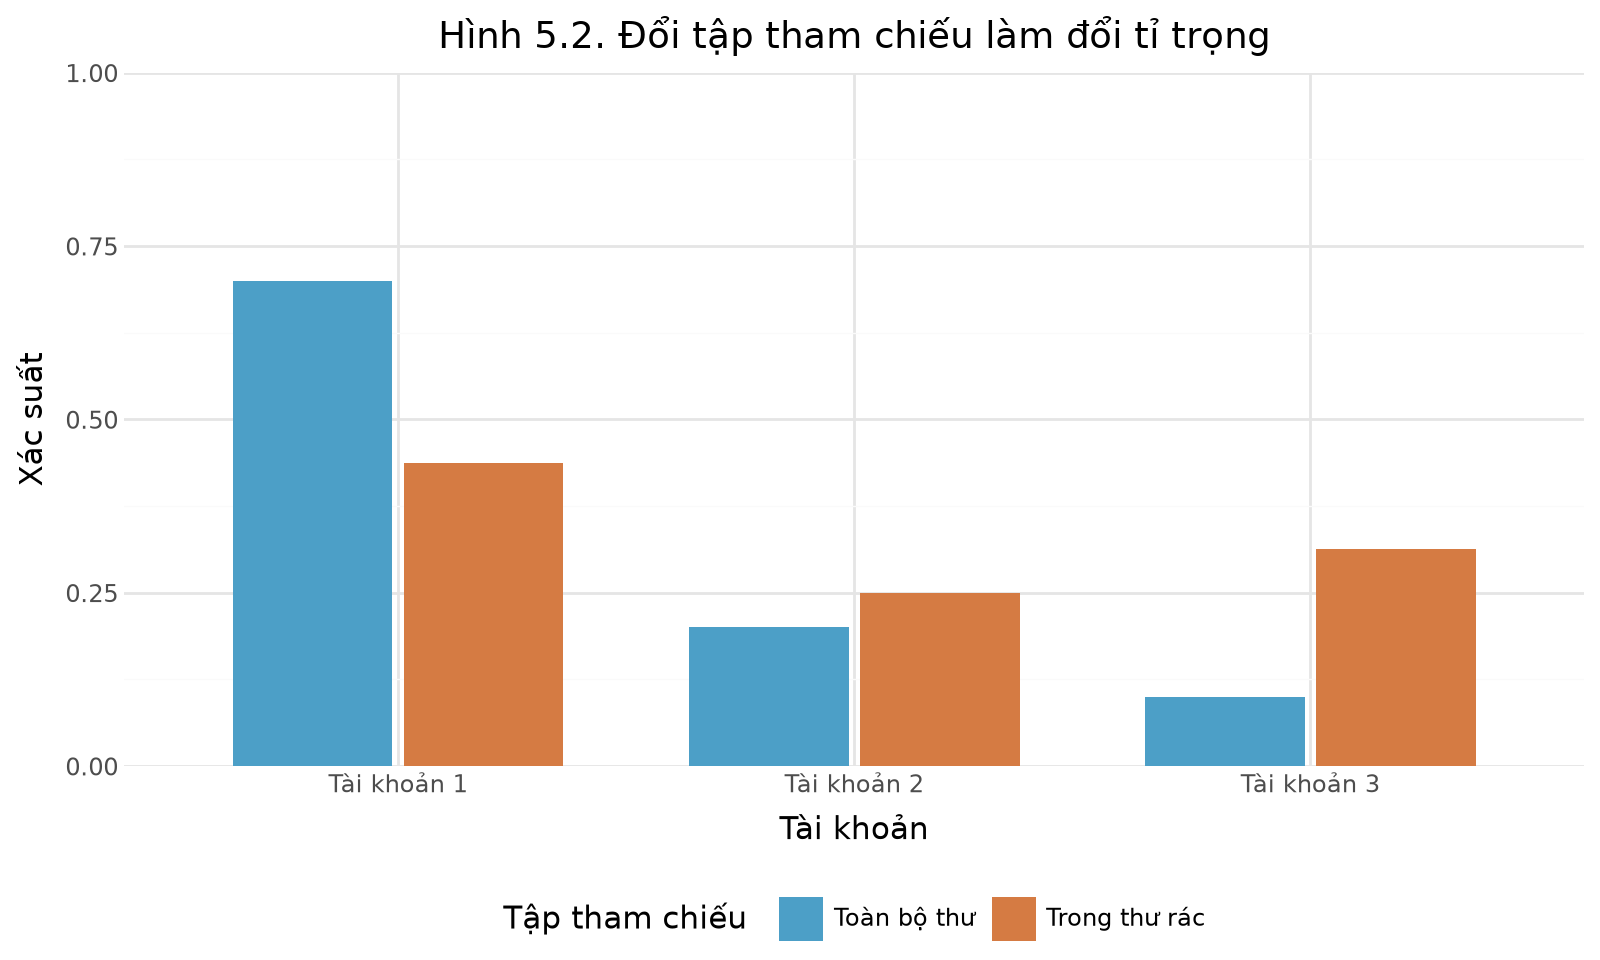

In [12]:
prior = np.array([0.70, 0.20, 0.10])
spam_rate = np.array([0.01, 0.02, 0.05])
joint = prior * spam_rate
posterior = joint / joint.sum()
display(pd.DataFrame({"Tài khoản": [1, 2, 3], "Ban đầu": prior,
                      "Thư rác trong nhóm": spam_rate,
                      "Nhóm và thư rác": joint, "Sau khi biết rác": posterior}))
# Dữ liệu dạng dài: mỗi hàng là một tài khoản trong một tập tham chiếu.
account_plot_data = pd.DataFrame({"Tài khoản": ["Tài khoản 1", "Tài khoản 2", "Tài khoản 3"],
                                  "Toàn bộ thư": prior, "Trong thư rác": posterior}).melt(
    id_vars="Tài khoản", var_name="Tập tham chiếu", value_name="Xác suất")
account_plot = (
    p9.ggplot(account_plot_data, p9.aes("Tài khoản", "Xác suất", fill="Tập tham chiếu"))
    + p9.geom_col(position=p9.position_dodge(width=0.75), width=0.70)
    + p9.scale_fill_manual(values={"Toàn bộ thư": "#4C9FC7", "Trong thư rác": "#D57B43"})
    + p9.scale_y_continuous(limits=(0, 1), expand=(0, 0))
    + p9.labs(title="Hình 5.2. Đổi tập tham chiếu làm đổi tỉ trọng", x="Tài khoản", y="Xác suất")
    + p9.theme(figure_size=(8, 4.8), legend_position="bottom")
)
display(account_plot)


Tài khoản 1 giảm tỉ trọng, tài khoản 2 và 3 tăng. Cột màu là hai phân phối với hai mẫu số khác nhau. Theo Ngữ pháp đồ họa đã học: dữ liệu là bảng tỉ trọng, trục x ánh xạ tài khoản, trục y ánh xạ xác suất, màu ánh xạ tập tham chiếu, dạng hình học là cột. Cách đọc đó dùng được khi đổi thư viện vẽ. Hình 5.2 là minh họa tính toán bổ sung cho bảng của slide trang 66.

### W05-EX05 — Mức độ 3: Mô hình SIR

Trong quần thể của bài toán, 60% cảm nhiễm S (chưa nhiễm nhưng có thể nhiễm), 10% đang nhiễm I, 30% hồi phục R. Xét nghiệm âm tính đúng ở 95% S; dương tính đúng ở 99% I; âm tính đúng ở 65% R. Biết kết quả dương tính, tính xác suất thực sự đang nhiễm.

<details><summary>Đáp án và lập luận — W05-EX05</summary><div><p>$P(+)=0{,}60(0{,}05)+0{,}10(0{,}99)+0{,}30(0{,}35)=0{,}234$. $P(I\mid+)=0{,}099/0{,}234=11/26\approx0{,}4231$. Xác suất tăng từ 0,10 lên khoảng 0,4231. Đây là tham số giả định của bài toán, không phải hiệu năng của một xét nghiệm thực tế.</p> </div></details>

### Hình 5.3. Sơ đồ cây của W05-EX05

Mỗi đường đi gồm xác suất nhóm và xác suất kết quả **trong nhóm đó**. Nhân dọc đường đi để có xác suất đồng thời. Các đường đi đến dương tính rời nhau nên cộng được. Em hãy chỉ trên cây đâu là $P(I)$, đâu là $P(+\mid I)$ và đâu là $P(I\cap+)$.

Nguồn: tái dựng `Slides/week05.pdf`, trang 68, với toàn bộ tham số của W05-EX05. S và R có xác suất dương tính lần lượt 5% và 35% vì phải lấy phần bù của tỉ lệ âm tính đúng.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_label` đặt nhãn từ biến `label` và vẽ nền quanh chữ. `geom_segment` nối cặp tọa độ đầu–cuối `x`, `y`, `xend`, `yend`. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

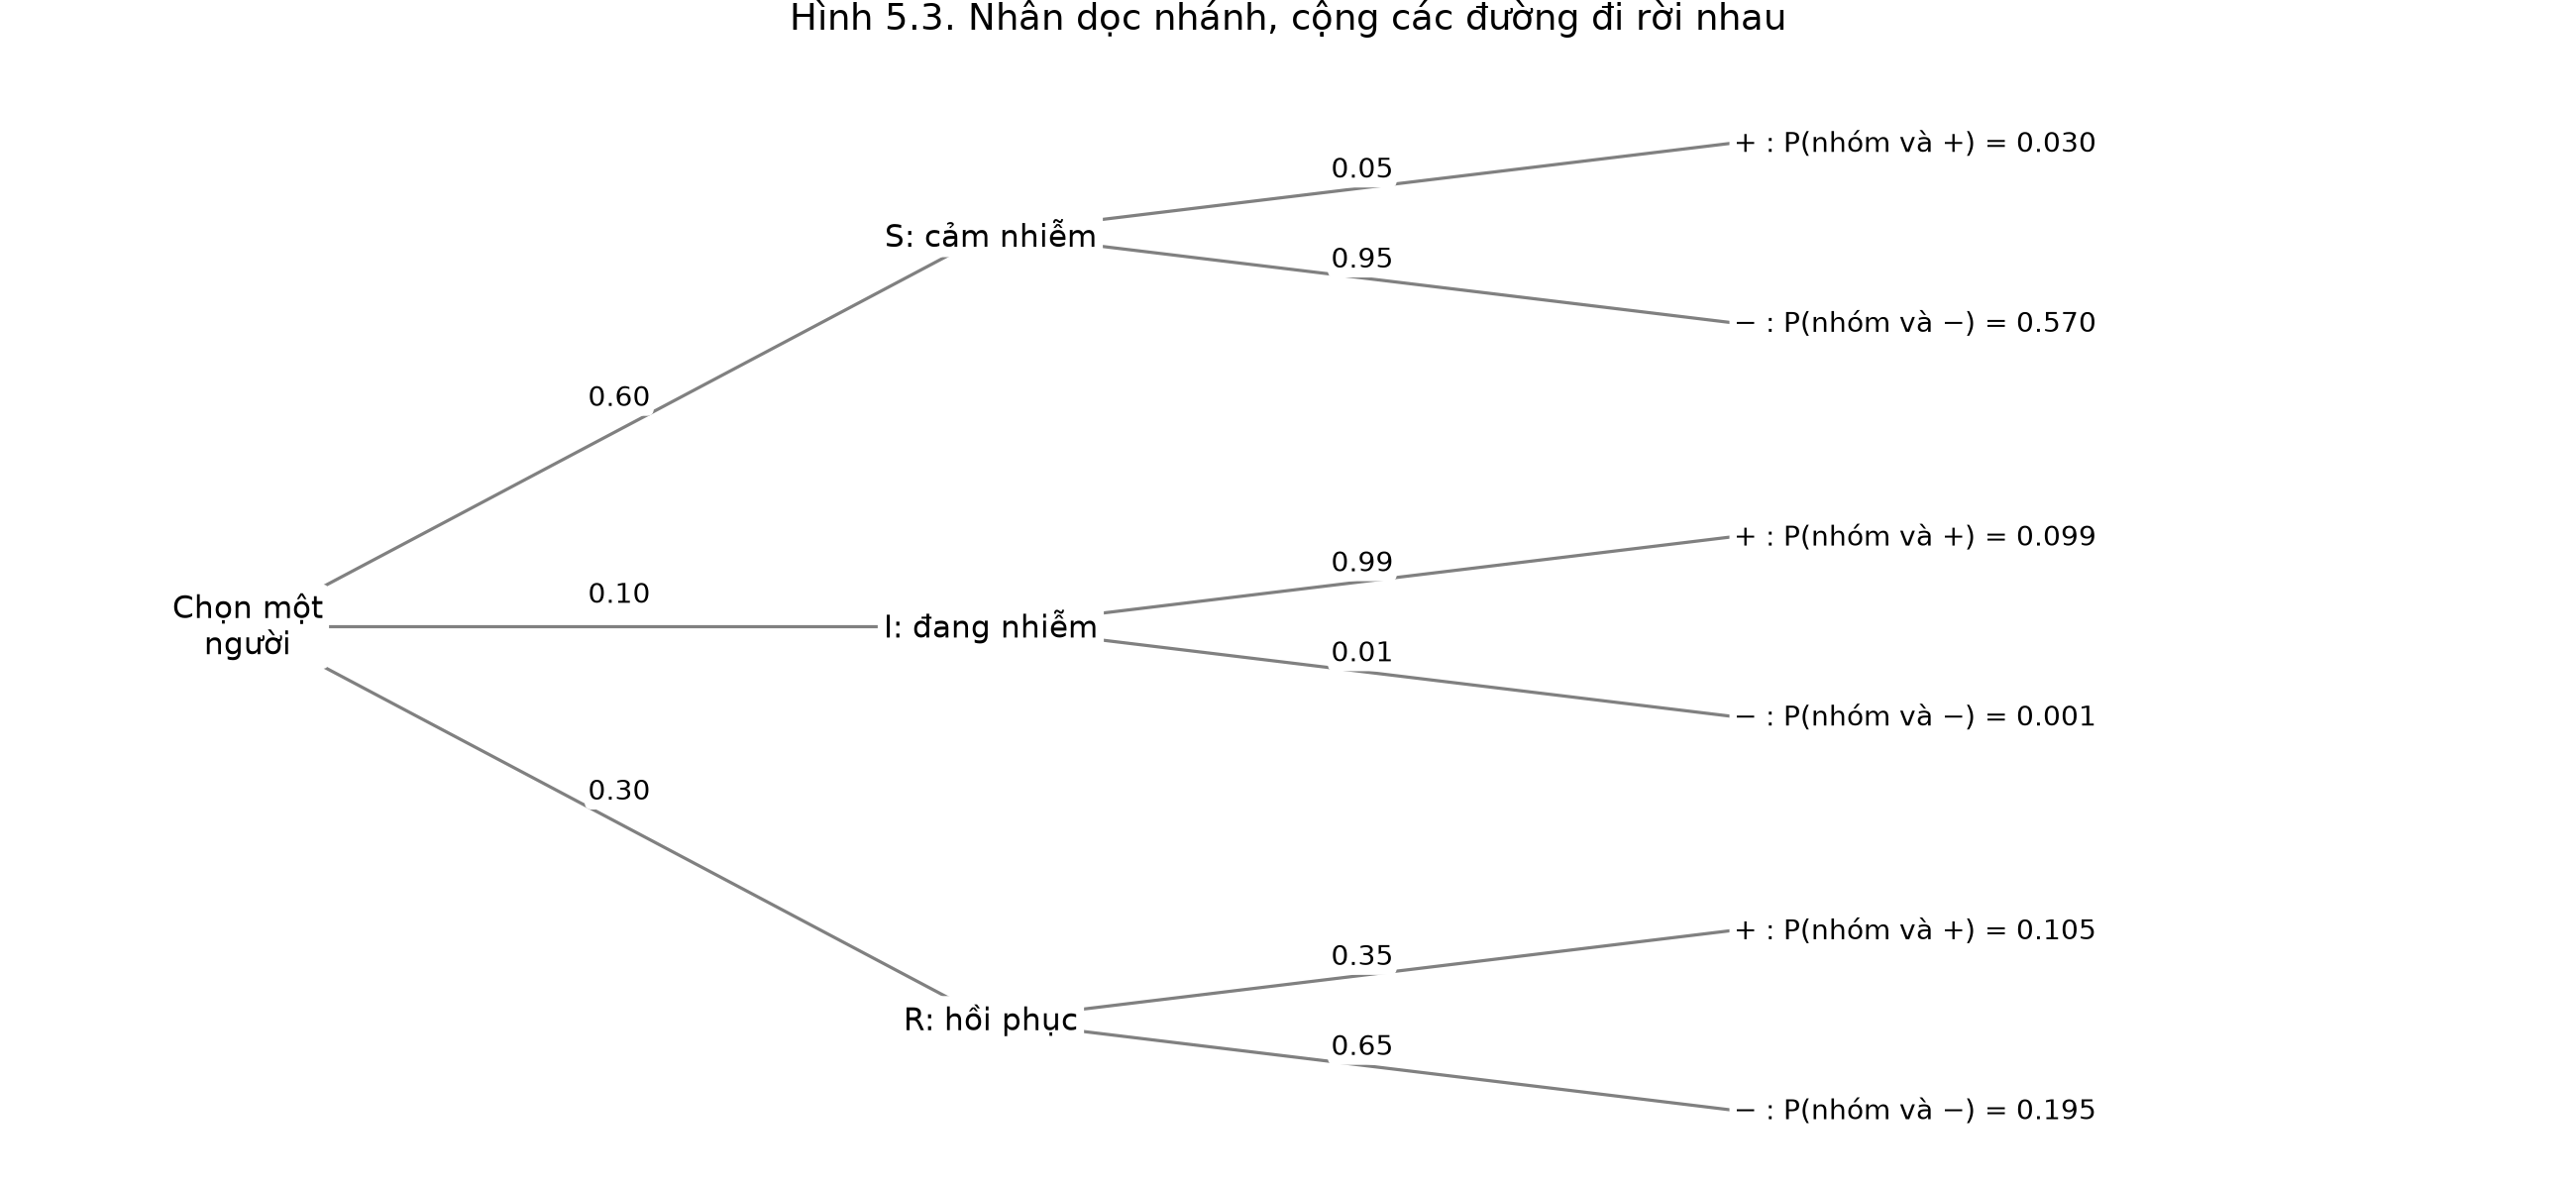

In [13]:
groups = ["S: cảm nhiễm", "I: đang nhiễm", "R: hồi phục"]
group_probs = np.array([0.60, 0.10, 0.30])
positive_probs = np.array([0.05, 0.99, 0.35])
# Ba bảng giữ riêng nhánh, xác suất trên nhánh và nhãn kết quả.
segments, branch_labels, group_nodes, leaf_nodes = [], [], [], []
for i, (name, p_group, p_plus) in enumerate(zip(groups, group_probs, positive_probs)):
    y = 0.85 - i * 0.35
    segments.append({"x": 0.0, "y": 0.5, "xend": 3.0, "yend": y})
    branch_labels.append({"x": 1.5, "y": (0.5+y)/2+0.03, "label": f"{p_group:.2f}"})
    group_nodes.append({"x": 3.0, "y": y, "label": name})
    for sign, p_test, delta in [("+", p_plus, 0.08), ("−", 1-p_plus, -0.08)]:
        segments.append({"x": 3.0, "y": y, "xend": 6.0, "yend": y+delta})
        branch_labels.append({"x": 4.5, "y": y+delta/2+0.018, "label": f"{p_test:.2f}"})
        leaf_nodes.append({"x": 6.0, "y": y+delta,
                           "label": f"{sign} : P(nhóm và {sign}) = {p_group*p_test:.3f}"})
root_node = pd.DataFrame({"x": [0.0], "y": [0.5], "label": ["Chọn một\nngười"]})
sir_tree = (
    p9.ggplot()
    + p9.geom_segment(pd.DataFrame(segments), p9.aes("x", "y", xend="xend", yend="yend"),
                      color="gray", size=0.65)
    + p9.geom_label(pd.DataFrame(branch_labels), p9.aes("x", "y", label="label"),
                    size=10, label_size=0, label_padding=0.12)
    + p9.geom_label(pd.DataFrame(group_nodes), p9.aes("x", "y", label="label"),
                    size=11, label_size=0, label_padding=0.2)
    + p9.geom_label(root_node, p9.aes("x", "y", label="label"), size=11,
                    label_size=0, label_padding=0.2)
    + p9.geom_label(pd.DataFrame(leaf_nodes), p9.aes("x", "y", label="label"),
                    ha="left", size=10, label_size=0, label_padding=0.16)
    + p9.coord_cartesian(xlim=(-1.0, 9.4), ylim=(0, 1), expand=False)
    + p9.labs(title="Hình 5.3. Nhân dọc nhánh, cộng các đường đi rời nhau")
    + p9.theme_void()
    + p9.theme(figure_size=(13, 6))
)
display(sir_tree)


Chỉ ba lá dương tính đóng góp vào mẫu số 0,234. Lá “I và +” đóng góp 0,099 vào tử số. Lấy 0,99 làm đáp án sẽ nhầm xác suất dương tính trong nhóm đang nhiễm với xác suất đang nhiễm trong nhóm dương tính.

Hoạt động bổ sung sau cho phép đổi tỉ lệ nhóm đang nhiễm, giữ tỉ lệ S:R bằng 2:1 trong phần còn lại và giữ các tỉ lệ xét nghiệm của bài. Thanh trượt thay đổi **mô hình giả định**, không cập nhật dữ liệu thực tế. Hãy dự đoán: tỉ lệ I càng nhỏ thì cùng một kết quả dương tính còn thuyết phục đến mức nào?

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Chạy ô để hiện hình ban đầu; widget cần kernel đang chạy. Đổi tham số của hàm vẽ và chạy lại nếu giao diện không hỗ trợ widget.

<!-- branch-plot-instructions:end -->

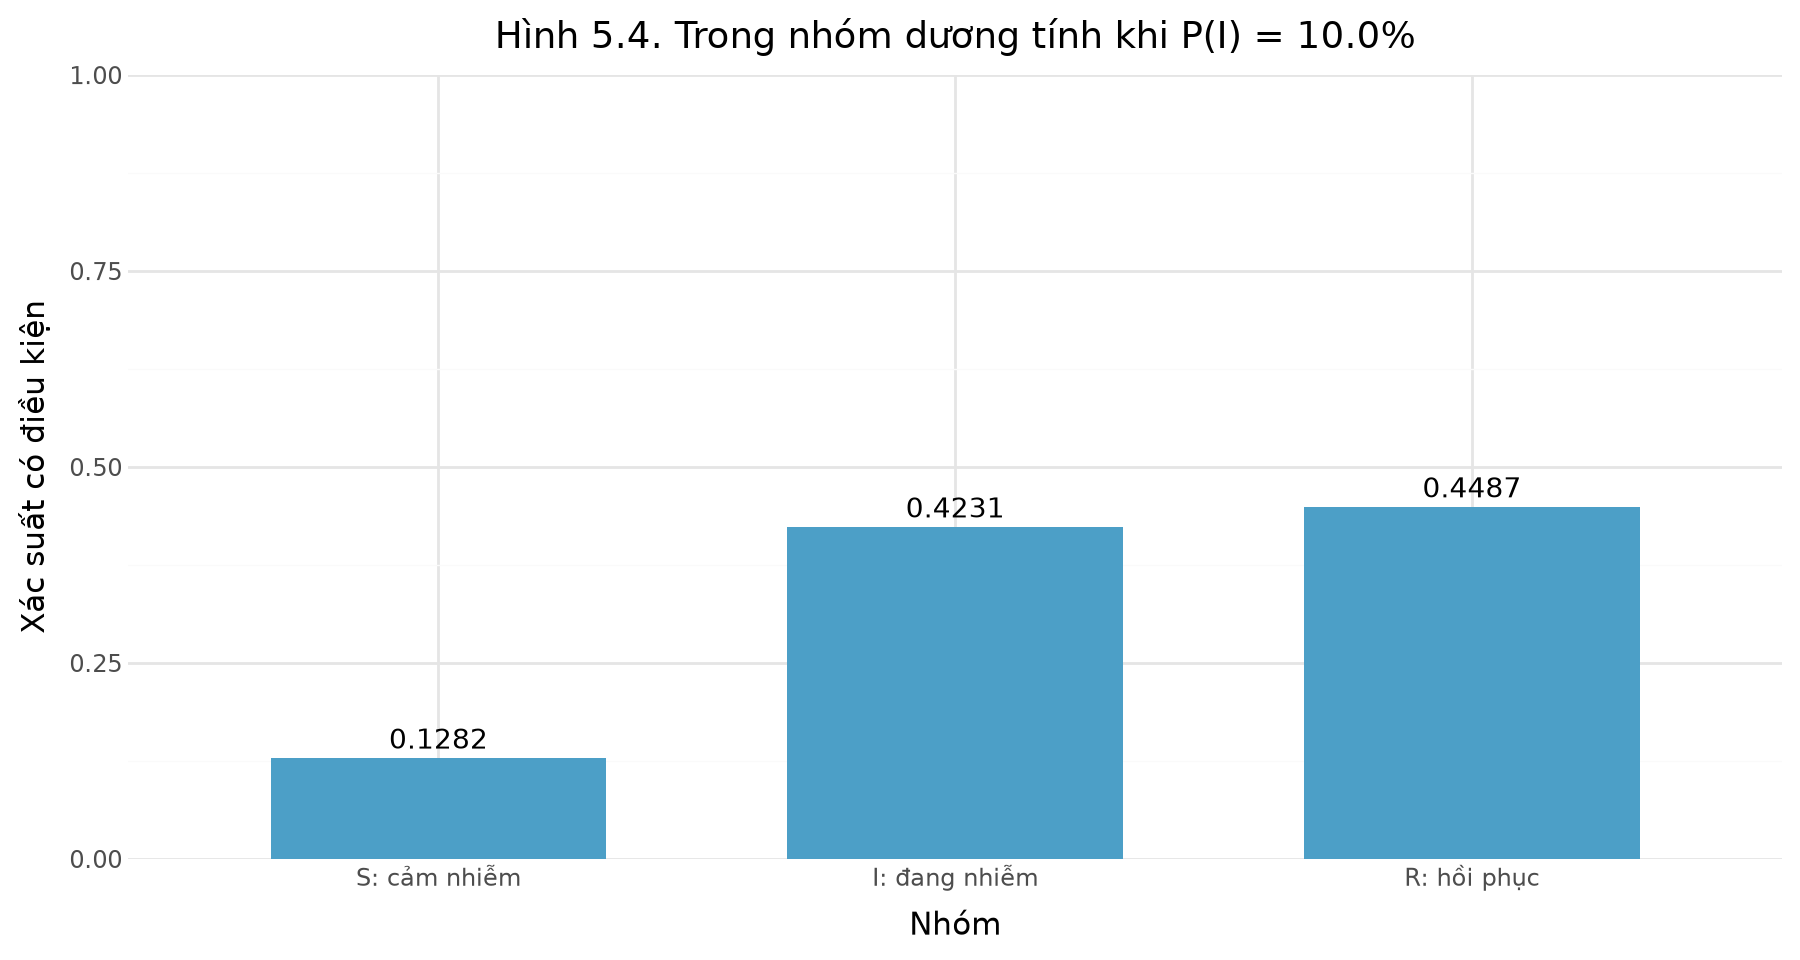

SelectionSlider(continuous_update=False, description='Tỉ lệ I:', index=3, layout=Layout(width='650px'), option…

In [14]:
prevalences = [0.001, 0.01, 0.05, 0.10, 0.30, 0.60]

def prevalence_plot(prevalence):
    weights = np.array([(1-prevalence)*2/3, prevalence, (1-prevalence)/3])
    positive_joint = weights * positive_probs
    result = positive_joint / positive_joint.sum()
    plot_data = pd.DataFrame({"Nhóm": pd.Categorical(groups, categories=groups, ordered=True),
                              "Xác suất có điều kiện": result})
    return (
        p9.ggplot(plot_data, p9.aes("Nhóm", "Xác suất có điều kiện"))
        + p9.geom_col(fill="#4C9FC7", width=0.65)
        + p9.geom_text(p9.aes(label="Xác suất có điều kiện"), format_string="{:.4f}",
                        nudge_y=0.025, size=10)
        + p9.scale_y_continuous(limits=(0, 1), expand=(0, 0))
        + p9.labs(title=f"Hình 5.4. Trong nhóm dương tính khi P(I) = {prevalence:.1%}",
                   x="Nhóm", y="Xác suất có điều kiện")
        + p9.theme(figure_size=(9, 4.8))
    )

# PNG ban đầu nằm ngay trong output để vẫn đọc được khi mở bản tĩnh.
prevalence = 0.10  # Có thể sửa giá trị này rồi chạy lại ô nếu không hiện widget.
bayes_display = display(prevalence_plot(prevalence), display_id=True)
try:
    import ipywidgets as widgets
    prevalence_slider = widgets.SelectionSlider(
        options=[(f"{p:.1%}", p) for p in prevalences], value=prevalence,
        description="Tỉ lệ I:", continuous_update=False,
        layout=widgets.Layout(width="650px"))

    def update_prevalence(change):
        bayes_display.update(prevalence_plot(change["new"]))

    prevalence_slider.observe(update_prevalence, names="value")
    display(prevalence_slider)
except ImportError:
    print("Để dùng thanh trượt cần ipywidgets; hiện có thể sửa prevalence rồi chạy lại ô.")


Khi nhóm I hiếm, nhiều kết quả dương tính có thể đến từ các nhóm khác dù xác suất dương tính trong I là 0,99. Xác suất sau cập nhật phụ thuộc cả tỉ lệ ban đầu lẫn xác suất bằng chứng trong mỗi nhóm. Thanh trượt chỉ thay mô hình trong Hình 5.4. Muốn đổi cây Hình 5.3, chỉnh `group_probs` và `positive_probs` trong ô dựng cây rồi chạy lại từ ô đó; giữ các xác suất nhóm có tổng bằng 1. Chạy lại từ ô thiết lập để khôi phục mô hình ban đầu.

## 6. Xung khắc, độc lập và lời giải De Méré

Nếu $A,B$ xung khắc và $P(A),P(B)>0$, thì $P(A\cap B)=0$ trong khi $P(A)P(B)>0$: chúng không độc lập. Biết A xảy ra loại trừ B. Nếu một biến cố có xác suất 0 thì đẳng thức độc lập vẫn có thể đúng; vì vậy phải giữ điều kiện “xác suất dương” trong phát biểu trên.

### W05-Q03 — Mức độ 1: Hai mặt khác nhau của một xúc xắc

Gieo một xúc xắc cân đối. A: mặt 1; B: mặt 6.

A. Độc lập vì hai mặt khác nhau.  
B. Xung khắc và độc lập.  
C. Xung khắc nhưng phụ thuộc.  
D. Là hai biến cố đối.

<details><summary>Đáp án và lập luận — W05-Q03</summary><div><p>Đáp án <strong>C</strong>. $P(A\cap B)=0$ nhưng $P(A)P(B)=1/36$. Khi biết A xảy ra, xác suất B giảm từ $1/6$ xuống 0. A và B không phủ hết không gian mẫu nên không đối nhau.</p> </div></details>

Với trò 1, **thua** nghĩa là cả bốn lần không ra 6. Xác suất không ra 6 mỗi lần là $5/6$; độc lập cho phép nhân bốn lần. Với trò 2, thua khi cả 24 lần không có cặp $(6,6)$, mỗi lần có xác suất $35/36$.

$$P(\text{thắng trò 1})=1-(5/6)^4\approx0{,}517747,$$
$$P(\text{thắng trò 2})=1-(35/36)^{24}\approx0{,}491404.$$

Hai số nằm ở hai phía của $1/2$. Hình sau tái dựng biểu đồ so sánh lý thuyết–mô phỏng ở slide trang 78. Trục xác suất bắt đầu từ 0 để cột biểu diễn độ lớn rõ ràng; đường ngang $1/2$ cho biết phía nào có xác suất thắng cao hơn xác suất thua.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='Trò chơi', y='Xác suất thắng', fill='Cách tính'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

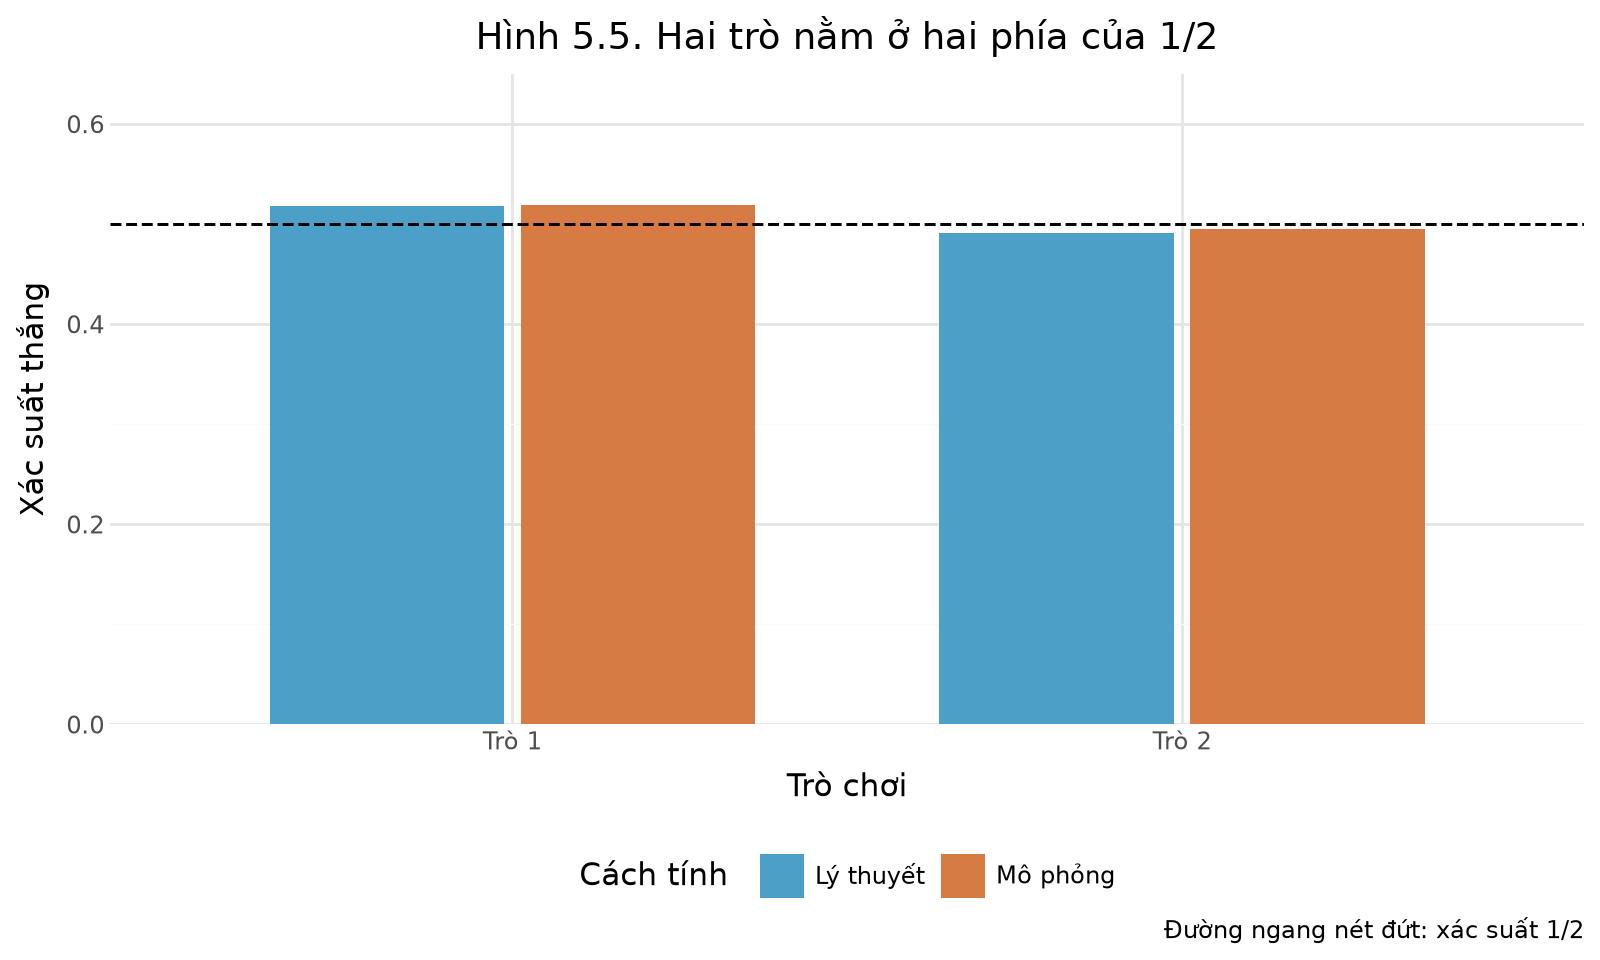

,Lý thuyết,Mô phỏng,Chênh lệch
Trò 1,0.517747,0.51874,0.000993
Trò 2,0.491404,0.49452,0.003116


In [15]:
exact_probs = np.array([1 - (5/6)**4, 1 - (35/36)**24])
sim_probs = np.array([win1.mean(), win2.mean()])
game_plot_data = pd.DataFrame({"Trò chơi": ["Trò 1", "Trò 2"],
                               "Lý thuyết": exact_probs, "Mô phỏng": sim_probs}).melt(
    id_vars="Trò chơi", var_name="Cách tính", value_name="Xác suất thắng")
comparison_plot = (
    p9.ggplot(game_plot_data, p9.aes("Trò chơi", "Xác suất thắng", fill="Cách tính"))
    + p9.geom_col(position=p9.position_dodge(width=0.75), width=0.70)
    + p9.geom_hline(yintercept=0.5, color="black", linetype="dashed", size=0.6)
    + p9.scale_fill_manual(values={"Lý thuyết": "#4C9FC7", "Mô phỏng": "#D57B43"})
    + p9.scale_y_continuous(limits=(0, 0.65), expand=(0, 0))
    + p9.labs(title="Hình 5.5. Hai trò nằm ở hai phía của 1/2", x="Trò chơi",
               y="Xác suất thắng", caption="Đường ngang nét đứt: xác suất 1/2")
    + p9.theme(figure_size=(8, 4.8), legend_position="bottom")
)
display(comparison_plot)
display(pd.DataFrame({"Lý thuyết": exact_probs, "Mô phỏng": sim_probs,
                      "Chênh lệch": sim_probs-exact_probs}, index=["Trò 1", "Trò 2"]))


Chênh lệch mô phỏng là dao động do số ván hữu hạn. Hình 5.6 bổ sung cho hoạt động mô phỏng: tại mỗi số ván m, lấy tổng số thắng từ ván 1 đến m chia cho m. `np.cumsum` cộng tích lũy; đường ngang giữ xác suất lý thuyết. Dự đoán phần nào của đường sẽ dao động mạnh nhất.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y', color='Trò chơi'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

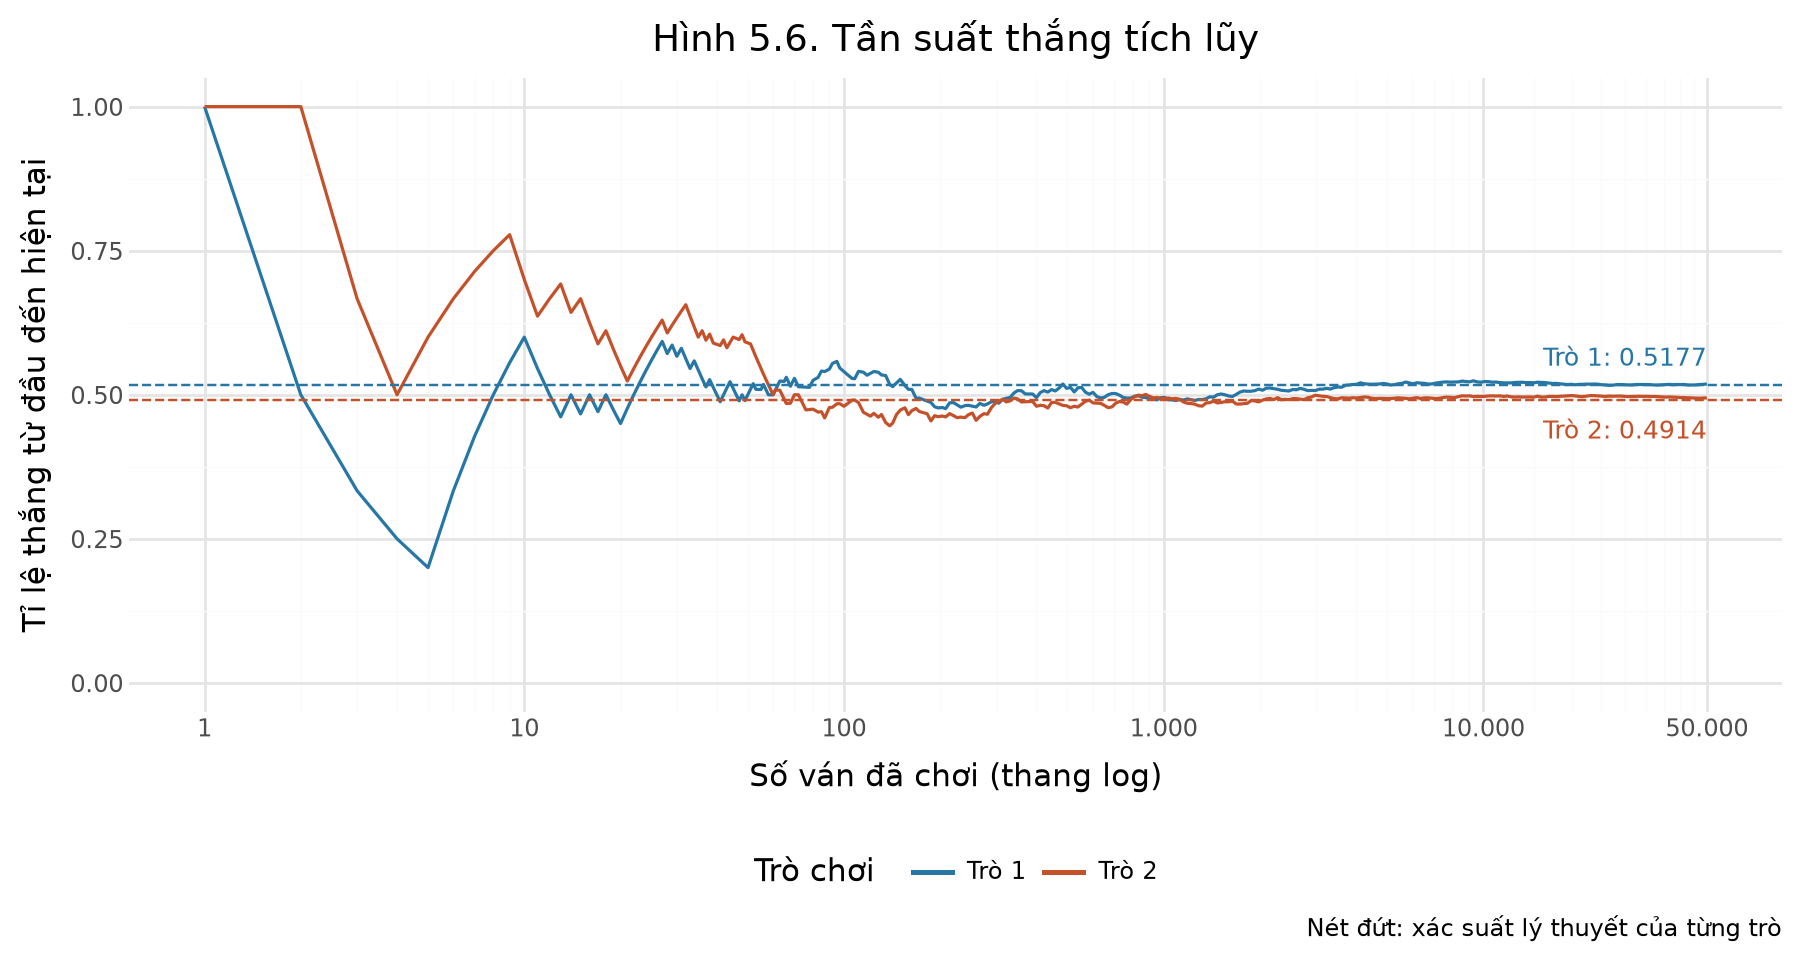

In [16]:
checkpoints = np.unique(np.geomspace(1, n_games, 400).astype(int))
rate_tables = []
for wins, theoretical, name in zip([win1, win2], exact_probs, ["Trò 1", "Trò 2"]):
    running_rate = np.cumsum(wins) / np.arange(1, n_games+1)
    rate_tables.append(pd.DataFrame({"Số ván": checkpoints,
                                      "Tỉ lệ thắng": running_rate[checkpoints-1], "Trò chơi": name}))
rate_data = pd.concat(rate_tables, ignore_index=True)
reference_data = pd.DataFrame({"Trò chơi": ["Trò 1", "Trò 2"], "Xác suất lý thuyết": exact_probs,
                               "x": [n_games, n_games], "y": exact_probs + np.array([0.05, -0.05]),
                               "label": [f"Trò 1: {exact_probs[0]:.4f}", f"Trò 2: {exact_probs[1]:.4f}"]})
log_breaks = [b for b in [1, 10, 100, 1000, 10000, 50000, 100000] if b <= n_games]
running_plot = (
    p9.ggplot(rate_data, p9.aes("Số ván", "Tỉ lệ thắng", color="Trò chơi"))
    + p9.geom_line(size=0.65)
    + p9.geom_hline(reference_data, p9.aes(yintercept="Xác suất lý thuyết", color="Trò chơi"),
                    inherit_aes=False, linetype="dashed", show_legend=False)
    + p9.geom_text(reference_data, p9.aes("x", "y", label="label", color="Trò chơi"),
                    inherit_aes=False, ha="right", size=9, show_legend=False)
    + p9.scale_x_log10(breaks=log_breaks, labels=[f"{b:,}".replace(",", ".") for b in log_breaks])
    + p9.scale_y_continuous(limits=(0, 1))
    + p9.scale_color_manual(values={"Trò 1": "#2677A6", "Trò 2": "#C4512A"})
    + p9.labs(title="Hình 5.6. Tần suất thắng tích lũy", x="Số ván đã chơi (thang log)",
               y="Tỉ lệ thắng từ đầu đến hiện tại", caption="Nét đứt: xác suất lý thuyết của từng trò")
    + p9.theme(figure_size=(9, 4.8), legend_position="bottom")
)
display(running_plot)


Đoạn đầu có rất ít ván nên một lần thắng hoặc thua làm tỉ lệ đổi nhiều. Khi số ván tăng, dao động thường nhỏ hơn và hai đường ở gần xác suất lý thuyết. Không có bảo đảm mọi điểm sau đều gần hơn điểm trước. Thử `n_games = 1000` hoặc `100000`, rồi chạy lại notebook; số ván lớn hơn cần thêm thời gian và bộ nhớ.

### W05-CH01 — Mức độ 3: Ít nhất một mô-đun lỗi

Hệ thống có n mô-đun độc lập, mỗi mô-đun lỗi trong ngày với xác suất p. (1) Lập công thức ít nhất một lỗi; (2) với p=0,02, tìm n nguyên nhỏ nhất để xác suất vượt 0,5; (3) vì sao không dùng np làm xác suất chính xác?

<details><summary>Đáp án và lập luận — W05-CH01</summary><div><p>$P(\text{ít nhất một lỗi})=1-(1-p)^n$. Với $p=0{,}02$, $n&gt;\log(0{,}5)/\log(0{,}98)\approx34{,}31$, nên $n=35$. $np$ cộng các biến cố không xung khắc, đếm lặp trường hợp nhiều lỗi và có thể vượt 1.</p> </div></details>

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='Số mô-đun n', y='Giá trị', color='Cách tính'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

Số mô-đun nhỏ nhất: 35
n=34: 0.49686263202236935 ; n=35: 0.506925379381922


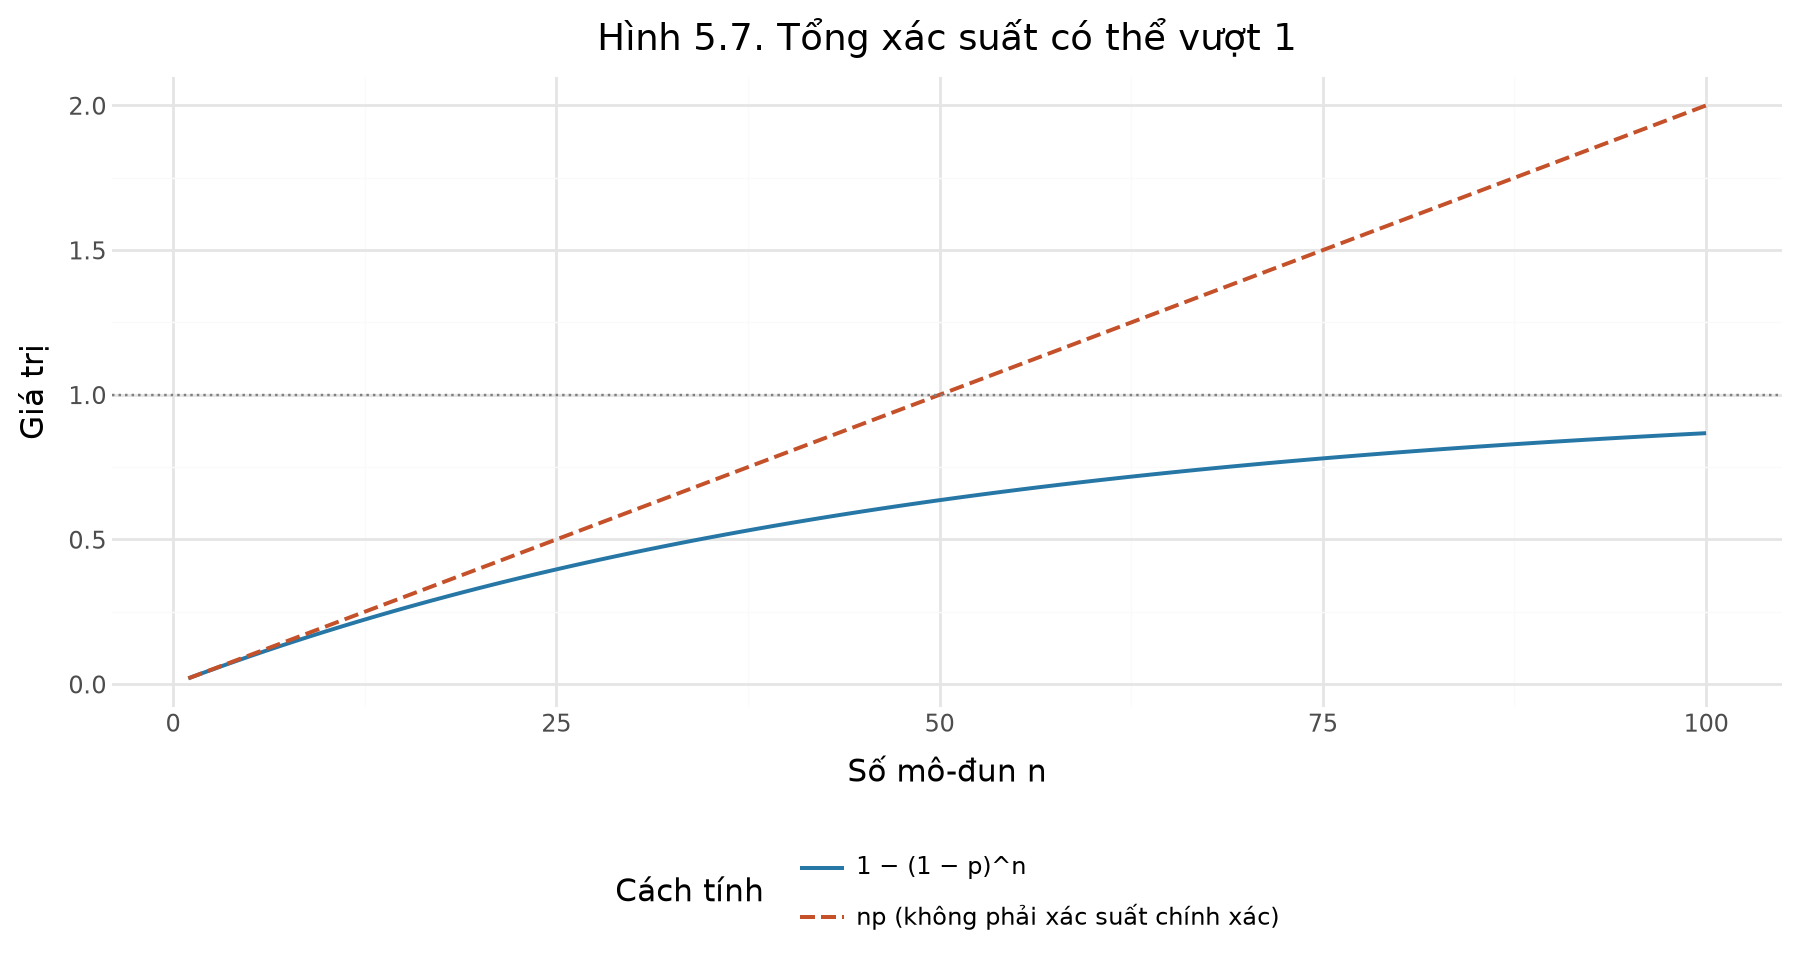

In [17]:
module_count = np.arange(1, 101)
failure_p = 0.02
at_least_one_failure = 1 - (1-failure_p)**module_count
first_over_half = module_count[at_least_one_failure > 0.5][0]
print("Số mô-đun nhỏ nhất:", first_over_half)
print("n=34:", 1-0.98**34, "; n=35:", 1-0.98**35)
failure_data = pd.DataFrame({"Số mô-đun n": module_count,
                             "1 − (1 − p)^n": at_least_one_failure,
                             "np (không phải xác suất chính xác)": module_count*failure_p}).melt(
    id_vars="Số mô-đun n", var_name="Cách tính", value_name="Giá trị")
failure_plot = (
    p9.ggplot(failure_data, p9.aes("Số mô-đun n", "Giá trị", color="Cách tính", linetype="Cách tính"))
    + p9.geom_line(size=0.8)
    + p9.geom_hline(yintercept=1, color="gray", linetype="dotted")
    + p9.scale_color_manual(values=["#2677A6", "#C4512A"])
    + p9.scale_linetype_manual(values=["solid", "dashed"])
    + p9.labs(title="Hình 5.7. Tổng xác suất có thể vượt 1", x="Số mô-đun n", y="Giá trị")
    + p9.guides(color=p9.guide_legend(nrow=2), linetype=p9.guide_legend(nrow=2))
    + p9.theme(figure_size=(9, 4.8), legend_position="bottom")
)
display(failure_plot)


Xác suất chính xác nằm trong [0,1]; đường np vượt 1 khi n > 50. Đây là minh họa bổ sung cho W05-CH01. Khi p nhỏ và np cũng nhỏ, np có thể gần xác suất chính xác, nhưng sự gần đó không biến phép cộng thành đẳng thức.

## 7. Bài tập tổng hợp

### W05-CASE01 — Mức độ 3: Hai thiết bị báo cháy

Khi đã có cháy, D1 báo đúng với xác suất 0,95 và D2 với 0,92; chúng hoạt động độc lập trong điều kiện này. Hệ chữa cháy hoạt động khi ít nhất một thiết bị báo đúng. Tính (a) cả hai báo đúng; (b) hệ hoạt động; (c) hệ không hoạt động.

<details><summary>Đáp án và lập luận — W05-CASE01</summary><div><p>Xét trong điều kiện có cháy. (a) $0{,}95(0{,}92)=0{,}874$. (b) $0{,}95+0{,}92-0{,}874=0{,}996$. (c) $1-0{,}996=0{,}004$. Cũng có thể tính c bằng $(0{,}05)(0{,}08)$. Không dùng các số này cho tình huống chưa biết có cháy.</p> </div></details>

### W05-TH01: Chuyển bi giữa hai hộp

Hộp 1 có 2 trắng, 1 đen; hộp 2 có 1 trắng, 5 đen. Chọn đều một viên từ hộp 1, chuyển sang hộp 2, trộn đều rồi chọn đều một viên hộp 2. (1) Vẽ cây; (2) tính xác suất lần lấy hộp 2 được trắng; (3) biết lần đó trắng, tính xác suất viên đã chuyển cũng trắng.

<details><summary>Đáp án và lập luận — W05-TH01</summary><div><p>A: chuyển trắng, B: rút hộp 2 được trắng. $P(A)=2/3$, $P(A^c)=1/3$.</p> <table> <thead> <tr>   <th>Nhánh</th>   <th>Hộp 2 sau chuyển</th>   <th style="text-align:right">$P(B\mid\text{nhánh})$</th>   <th style="text-align:right">$P(B^c\mid\text{nhánh})$</th> </tr> </thead> <tbody> <tr>   <td>A</td>   <td>2 trắng, 5 đen</td>   <td style="text-align:right">2/7</td>   <td style="text-align:right">5/7</td> </tr> <tr>   <td>$A^c$</td>   <td>1 trắng, 6 đen</td>   <td style="text-align:right">1/7</td>   <td style="text-align:right">6/7</td> </tr> </tbody> </table> <p>Nhân theo nhánh, cộng hai đường đi đến B: $P(B)=(2/3)(2/7)+(1/3)(1/7)=5/21$. Bayes cho $P(A\mid B)=[(2/3)(2/7)]/(5/21)=4/5$. Xác suất chuyển trắng tăng từ 2/3 lên 4/5.</p> </div></details>

Ô tiếp theo vẽ đúng hai bước của W05-TH01. Dọc nhánh “chuyển trắng rồi rút trắng”, xác suất đường đi là 4/21. Dọc nhánh “chuyển đen rồi rút trắng”, xác suất là 1/21. Tổng 5/21 là mẫu số cho câu 3.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_label` đặt nhãn từ biến `label` và vẽ nền quanh chữ. `geom_segment` nối cặp tọa độ đầu–cuối `x`, `y`, `xend`, `yend`. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

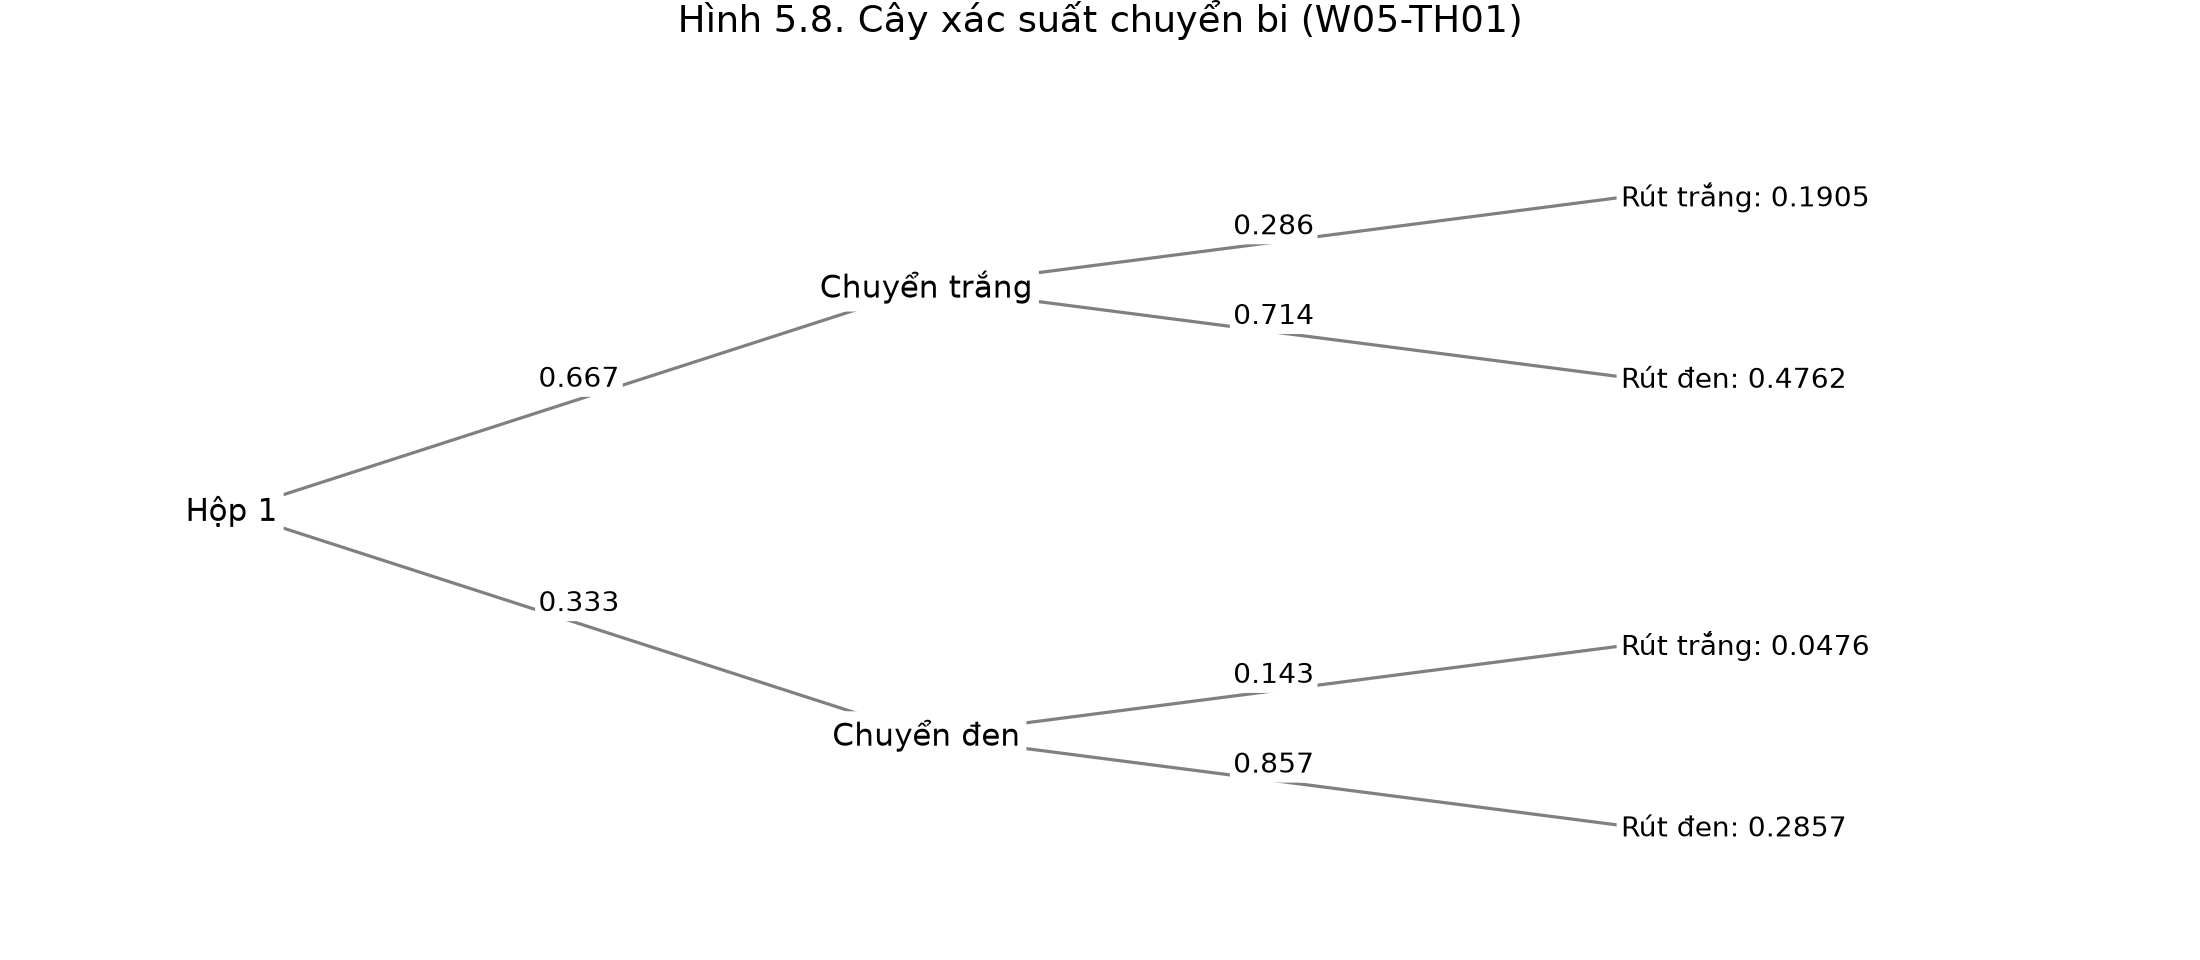

In [18]:
segments, branch_labels, transfer_nodes, outcome_nodes = [], [], [], []
for label, p_first, y, p_white in [("Chuyển trắng", 2/3, 0.75, 2/7),
                                   ("Chuyển đen", 1/3, 0.25, 1/7)]:
    segments.append({"x": 0.0, "y": 0.5, "xend": 3.0, "yend": y})
    branch_labels.append({"x": 1.5, "y": (0.5+y)/2+0.025, "label": f"{p_first:.3f}"})
    transfer_nodes.append({"x": 3.0, "y": y, "label": label})
    for second, p_second, delta in [("Rút trắng", p_white, 0.1), ("Rút đen", 1-p_white, -0.1)]:
        segments.append({"x": 3.0, "y": y, "xend": 6.0, "yend": y+delta})
        branch_labels.append({"x": 4.5, "y": y+delta/2+0.02, "label": f"{p_second:.3f}"})
        outcome_nodes.append({"x": 6.0, "y": y+delta, "label": f"{second}: {p_first*p_second:.4f}"})
root_node = pd.DataFrame({"x": [0.0], "y": [0.5], "label": ["Hộp 1"]})
transfer_tree = (
    p9.ggplot()
    + p9.geom_segment(pd.DataFrame(segments), p9.aes("x", "y", xend="xend", yend="yend"),
                      color="gray", size=0.65)
    + p9.geom_label(pd.DataFrame(branch_labels), p9.aes("x", "y", label="label"),
                    size=10, label_size=0, label_padding=0.12)
    + p9.geom_label(pd.DataFrame(transfer_nodes), p9.aes("x", "y", label="label"),
                    size=11, label_size=0, label_padding=0.2)
    + p9.geom_label(root_node, p9.aes("x", "y", label="label"), size=11,
                    label_size=0, label_padding=0.2)
    + p9.geom_label(pd.DataFrame(outcome_nodes), p9.aes("x", "y", label="label"),
                    ha="left", size=10, label_size=0, label_padding=0.16)
    + p9.coord_cartesian(xlim=(-1, 8.5), ylim=(0, 1), expand=False)
    + p9.labs(title="Hình 5.8. Cây xác suất chuyển bi (W05-TH01)")
    + p9.theme_void()
    + p9.theme(figure_size=(11, 4.8))
)
display(transfer_tree)


### W05-TH03: Truy loại lô từ hai linh kiện kiểm tra

Lô có 10 linh kiện. Trong toàn bộ lô, 50% có 0 lỗi, 30% có 1 lỗi, 20% có 2 lỗi. Chọn đều một lô, lấy đều hai linh kiện khác nhau không hoàn lại, kiểm tra chính xác. Tính xác suất lô có 0/1/2 lỗi khi (1) cả hai được kiểm tra đều tốt; (2) đúng một linh kiện được kiểm tra bị lỗi.

<details><summary>Đáp án và lập luận — W05-TH03</summary><div><p>$A_i$: lô có i lỗi; B: hai tốt; C: đúng một lỗi.</p> <table> <thead> <tr>   <th>Loại lô</th>   <th style="text-align:right">$P(A_i)$</th>   <th style="text-align:right">$P(B\mid A_i)$</th>   <th style="text-align:right">$P(C\mid A_i)$</th> </tr> </thead> <tbody> <tr>   <td>0 lỗi</td>   <td style="text-align:right">1/2</td>   <td style="text-align:right">1</td>   <td style="text-align:right">0</td> </tr> <tr>   <td>1 lỗi</td>   <td style="text-align:right">3/10</td>   <td style="text-align:right">$(9/10)(8/9)=4/5$</td>   <td style="text-align:right">$2(1/10)(9/9)=1/5$</td> </tr> <tr>   <td>2 lỗi</td>   <td style="text-align:right">1/5</td>   <td style="text-align:right">$(8/10)(7/9)=28/45$</td>   <td style="text-align:right">$2(2/10)(8/9)=16/45$</td> </tr> </tbody> </table> <p>Hai thứ tự lỗi–tốt và tốt–lỗi xung khắc nên cộng được. Lần rút thứ hai dùng thành phần lô đã thay đổi.</p> <p>$P(B)=1/2+(3/10)(4/5)+(1/5)(28/45)=389/450$.</p> <p>$(P(A_0\mid B),P(A_1\mid B),P(A_2\mid B))=(225/389,108/389,56/389)\approx(0{,}5784,0{,}2776,0{,}1440)$.</p> <p>$P(C)=(3/10)(1/5)+(1/5)(16/45)=59/450$.</p> <p>$(P(A_0\mid C),P(A_1\mid C),P(A_2\mid C))=(0,27/59,32/59)\approx(0,0{,}4576,0{,}5424)$.</p> <p>Hai tốt chưa bảo đảm cả lô tốt. Đúng một lỗi loại trừ lô 0 lỗi, và làm loại 2 lỗi có xác suất sau cập nhật lớn nhất.</p> </div></details>

Ô sau kiểm tra bảng W05-TH03 bằng phép liệt kê 90 cặp chỉ số khác nhau. `k` linh kiện đầu được gắn là lỗi để đại diện cho loại lô có k lỗi; các nhãn không ảnh hưởng xác suất vì mọi cặp đều đồng khả năng. Không cần học công thức siêu bội ở buổi này: Tuần 06 sẽ viết lại phép đếm này thành một phân phối.

In [19]:
lot_prior = np.array([0.5, 0.3, 0.2])
sample_pairs = np.array([(i, j) for i in range(10) for j in range(10) if i != j])
likelihoods = []
for k in [0, 1, 2]:
    observed_defects = (sample_pairs < k).sum(axis=1)
    likelihoods.append([(observed_defects == 0).mean(), (observed_defects == 1).mean()])
likelihoods = np.array(likelihoods)
lot_joint = lot_prior[:, None] * likelihoods
evidence_probs = lot_joint.sum(axis=0)
lot_posterior = lot_joint / evidence_probs
display(pd.DataFrame({"Loại lô (số lỗi)": [0, 1, 2], "Ban đầu": lot_prior,
                      "P(hai tốt | loại)": likelihoods[:, 0],
                      "P(một lỗi | loại)": likelihoods[:, 1],
                      "Sau hai tốt": lot_posterior[:, 0], "Sau một lỗi": lot_posterior[:, 1]}))
print("P(hai tốt), P(một lỗi):", evidence_probs)
assert np.allclose(lot_posterior.sum(axis=0), 1)
assert np.allclose(lot_posterior[:, 0], np.array([225, 108, 56])/389)
assert np.allclose(lot_posterior[:, 1], np.array([0, 27, 32])/59)

,Loại lô (số lỗi),Ban đầu,P(hai tốt | loại),P(một lỗi | loại),Sau hai tốt,Sau một lỗi
0,0,0.5,1.000000,0.000000,0.578406,0.000000
1,1,0.3,0.800000,0.200000,0.277635,0.457627
2,2,0.2,0.622222,0.355556,0.143959,0.542373


P(hai tốt), P(một lỗi): [0.86444444 0.13111111]


## 8. Đọc các hình minh họa của STAT20 tiếng Việt (bổ sung)

Các hình dưới đây giữ nguyên từ bản dịch để em đối chiếu sơ đồ với phép tính Python. Đây là ảnh minh họa và sơ đồ; đồ thị dữ liệu của buổi học được dựng bằng code ở trên. Mỗi câu giải thích nêu cách đọc hình, không dùng kích thước vùng vẽ để suy ra xác suất nếu nguồn không nêu tỉ lệ diện tích.

### Hình 5.S1. Từ mô tả tới khái quát dữ liệu

Ta đã mô tả các quan sát hiện có; nhánh generalization hỏi về một tập đơn vị rộng hơn. Xác suất giúp mô hình hóa bước lấy mẫu và mức dao động, chứ không tự loại bỏ sai lệch do chọn mẫu.

![Hình 5.S1. Từ mô tả tới khái quát dữ liệu](figures/01_stat20_generalization_map.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3 Chương 3: Khái quát hóa dữ liệu: Lý thuyết xác suất; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S2. Bối cảnh trò chơi của De Méré

Tranh minh họa trò chơi đặt câu hỏi về một cơ chế lặp ngẫu nhiên. Hình không cung cấp dữ liệu để ước lượng xác suất; các số chính xác đến từ mô hình xúc xắc cân đối và độc lập đã nêu.

![Hình 5.S2. Bối cảnh trò chơi của De Méré](figures/02_stat20_de_mere_gambling.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.1 Nghịch lý của De Méré; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S3. Đồng xu và hai kết quả

Ảnh minh họa một đồng xu; mô hình phân biệt hai kết quả H và T. Chỉ với giả định cân đối mới gán xác suất 1/2 cho mỗi mặt. Không gian mẫu không cần chứa mọi chi tiết vật lý của cú tung.

![Hình 5.S3. Đồng xu và hai kết quả](figures/03_stat20_coin_photo.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.2.1 Ví dụ: Tung một đồng xu đồng chất; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S4. Hợp và giao trên sơ đồ Venn

Vùng thuộc ít nhất một vòng tròn là hợp; phần chồng lên nhau là giao. Đếm riêng hai vòng rồi cộng sẽ đếm vùng giao hai lần.

![Hình 5.S4. Hợp và giao trên sơ đồ Venn](figures/04_stat20_venn_union_intersection.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.4 Biểu đồ Venn; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S5. Hai biến cố xung khắc

Hai vòng không giao nhau. Xác suất hợp bằng tổng xác suất hai biến cố. Hai vùng vẫn chưa phủ hết hình chữ nhật, nên xung khắc chưa có nghĩa là đối nhau.

![Hình 5.S5. Hai biến cố xung khắc](figures/05_stat20_venn_disjoint.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.4 Biểu đồ Venn; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S6. Hộp năm vé: phân biệt vé với giá trị

Hộp trong nguồn có năm vé [1, 2, 2, 3, 4]. Chọn đều một vé: mỗi vé có xác suất 1/5 nhưng giá trị 2 có xác suất 2/5. Có bốn giá trị khác nhau không có nghĩa mỗi giá trị có xác suất 1/4.

![Hình 5.S6. Hộp năm vé: phân biệt vé với giá trị](figures/06_stat20_number_tickets_box.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.5.2 2. Một hộp vé 25; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S7. Đồng xu thiên vị bằng hộp H, H, T

Hộp [H,H,T] biểu diễn P(H)=2/3 và P(T)=1/3. Rút hai lần có hoàn lại: chín cặp vé có thứ tự đồng khả năng nhưng chuỗi mặt HH, HT, TH, TT có xác suất 4/9, 2/9, 2/9, 1/9. Chỉ được đếm đồng khả năng ở đúng cấp đơn vị.

![Hình 5.S7. Đồng xu thiên vị bằng hộp H, H, T](figures/07_stat20_biased_coin_tree.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.5.3 3. Tung một đồng xu thiên vị; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S8. Roulette và xác suất đỏ

Mô hình kiểu Mỹ dùng 38 ô: 18 đỏ, 18 đen, 2 xanh. Xác suất đỏ là 18/38. Ảnh chỉ minh họa bánh xe; hãy kiểm tra số ô của loại bánh xe trước khi dùng mô hình.

![Hình 5.S8. Roulette và xác suất đỏ](figures/08_stat20_roulette_wheel.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.1.5.4 4. Đặt cược vào màu đỏ trong trò roulette 26; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S9. Sally Clark trong câu chuyện của nguồn

Ảnh đi kèm trường hợp lịch sử đã phân tích ở phần 4. Hai vấn đề toán học là giả định độc lập và đảo chiều xác suất có điều kiện; ảnh không phải bằng chứng để tính một xác suất hậu nghiệm.

![Hình 5.S9. Sally Clark trong câu chuyện của nguồn](figures/09_stat20_sally_clark_photo.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.1 Sally Clark: một nạn nhân bi thảm của sự thiếu hiểu biết về thống kê; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S10. Hộp hai vé đỏ, hai vé xanh

Mỗi vé có thể được gắn nhãn R1, R2, B1, B2. Khi tính xác suất, nhãn giúp phân biệt các kết quả đồng khả năng; màu là một biến ghi trên vé.

![Hình 5.S10. Hộp hai vé đỏ, hai vé xanh](figures/10_stat20_red_blue_box.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.2.1 Ví dụ: Rút các vé màu đỏ và xanh từ một hộp; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S11. Ba lần lấy có hoàn lại

Hộp 2 đỏ, 2 xanh được giữ nguyên sau mỗi lần lấy. Tám chuỗi màu dài 3 có xác suất (1/2)^3=1/8. Đây là trường hợp cụ thể mà các chuỗi màu đồng khả năng.

![Hình 5.S11. Ba lần lấy có hoàn lại](figures/11_stat20_replacement_three_draws.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.2.1 Ví dụ: Rút các vé màu đỏ và xanh từ một hộp; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S12. Ba lần lấy không hoàn lại

Không thể lấy ba vé cùng màu từ hộp chỉ có hai vé mỗi màu. Sáu chuỗi màu còn lại đều có xác suất 1/6 trong phép thử ba lần này. Kết quả đó cần chứng minh từ các vé riêng biệt; không suy ra mọi phép lấy không hoàn lại đều có chuỗi màu đồng khả năng.

![Hình 5.S12. Ba lần lấy không hoàn lại](figures/12_stat20_without_replacement_three_draws.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.2.1 Ví dụ: Rút các vé màu đỏ và xanh từ một hộp; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S13. Hai lần lấy không hoàn lại: cây thay đổi

Nếu lần đầu lấy xanh, hộp còn 2 đỏ và 1 xanh. Các xác suất RR, RB, BR, BB lần lượt là 1/6, 1/3, 1/3, 1/6. Vì vậy bốn chuỗi màu của phép thử hai lần không đồng khả năng. Câu trong §3.3.3 nói còn hai vé xanh sau khi rút xanh được sửa theo thành phần hộp thực tế.

![Hình 5.S13. Hai lần lấy không hoàn lại: cây thay đổi](figures/13_stat20_without_replacement_tree.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.2.1 Ví dụ: Rút các vé màu đỏ và xanh từ một hộp; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S14. Phần giao trong quy tắc nhân

Vùng tím là A giao B. Có thể đi từ P(A) rồi nhân P(B | A), hoặc từ P(B) rồi nhân P(A | B); cả hai cùng đo một vùng giao.

![Hình 5.S14. Phần giao trong quy tắc nhân](figures/14_stat20_venn_intersection.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.4 Công thức nhân: tính xác suất của một giao; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S15. Đảo chiều điều kiện đổi mẫu số

Trong sơ đồ, B nhỏ và gần nằm trong A. P(A | B) gần 1 nhưng P(B | A) nhỏ. Tử số cùng là phần giao, mẫu số lần lượt là P(B) và P(A). Diện tích chỉ dùng để giải thích trực giác, không thay cho số liệu.

![Hình 5.S15. Đảo chiều điều kiện đổi mẫu số](figures/15_stat20_conditional_probability_direction.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.4 Công thức nhân: tính xác suất của một giao; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S16. Chọn hai người trong năm người

Có 10 cặp người không xét thứ tự. Nếu chọn đều hai người khác nhau và ghi thứ tự, có 5×4=20 cặp; mỗi cặp không thứ tự nhận hai thứ tự. Biết người đầu là một người cụ thể thì thành phần lựa chọn cho người tiếp theo đã thay đổi.

![Hình 5.S16. Chọn hai người trong năm người](figures/16_stat20_committee_five_people.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.5.1.1 (rút không hoàn lại); ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S17. Màu và số: kiểm tra độc lập trong từng hộp

Hộp 1 có đỏ 1,2,3 và xanh 1,2,4; sự kiện vé có số 3 phụ thuộc vào màu. Hộp 2 có đỏ 1,2,3 và xanh 1,2,3: phân phối số trong hai màu giống nhau. Độc lập phải kiểm tra bằng các xác suất, không chỉ qua tên màu và số.

![Hình 5.S17. Màu và số: kiểm tra độc lập trong từng hộp](figures/17_stat20_color_number_independence.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.5.2 Ví dụ: Các vé có màu và số; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S18. Vé có hai số trong hai hộp

Hộp 1 gồm (1,5),(1,6),(1,6),(2,5),(2,6),(2,6). Hộp 2 gồm (1,5),(1,6),(1,6),(2,4),(2,5),(2,6). Xem số đầu và số sau là hai biến; mỗi vé vẫn là một đơn vị được chọn đều.

![Hình 5.S18. Vé có hai số trong hai hộp](figures/18_stat20_two_numbers_boxes.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.5.3 Ví dụ: Các vé có nhiều hơn một số trên đó; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S19. Lọc theo số đầu bằng 1

Trong hộp 1, P(số sau=6)=4/6 và P(số sau=6 | số đầu=1)=2/3, không đổi. Trong hộp 2, hai số tương ứng là 3/6 và 2/3, nên thay đổi. Lọc dữ liệu và xác suất có điều kiện cùng yêu cầu xác định lại tập tham chiếu.

![Hình 5.S19. Lọc theo số đầu bằng 1](figures/19_stat20_conditioning_two_numbers.jpg)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.5.3 Ví dụ: Các vé có nhiều hơn một số trên đó; ảnh minh họa giữ nguyên từ nguồn.

### Hình 5.S20. Vì sao quy tắc cộng phải trừ phần giao

Hai lớp gạch chéo cùng phủ vùng giao. Cộng P(A) và P(B) đếm vùng đó hai lần; trừ một lần P(A giao B) để mỗi kết quả của hợp được tính đúng một lần.

![Hình 5.S20. Vì sao quy tắc cộng phải trừ phần giao](figures/20_stat20_inclusion_exclusion_venn.png)

Nguồn: `STAT20_in_Vietnamese.html`, 3.3.9 Bao hàm-loại trừ (quy tắc cộng tổng quát); ảnh minh họa giữ nguyên từ nguồn.

Ô sau kiểm tra riêng hai cấp kết quả trong hộp 2 đỏ, 2 xanh. `permutations` liệt kê vé riêng biệt khi không hoàn lại; `value_counts(normalize=True)` gom xác suất theo chuỗi màu. Dự đoán trước: hai lần lấy có bốn chuỗi màu nhưng không đều; ba lần lấy có sáu chuỗi màu và đều trong trường hợp này.

In [20]:
from itertools import permutations
ticket_colors = {"R1": "R", "R2": "R", "B1": "B", "B2": "B"}
for draw_count in [2, 3]:
    labeled_outcomes = list(permutations(ticket_colors, draw_count))
    color_sequences = ["".join(ticket_colors[t] for t in draw) for draw in labeled_outcomes]
    print("Số lần lấy:", draw_count, "; số kết quả vé có thứ tự:", len(labeled_outcomes))
    display(pd.Series(color_sequences).value_counts(normalize=True).sort_index().rename("Xác suất").to_frame())

Số lần lấy: 2 ; số kết quả vé có thứ tự: 12


,Xác suất
BB,0.166667
BR,0.333333
RB,0.333333
RR,0.166667


Số lần lấy: 3 ; số kết quả vé có thứ tự: 24


,Xác suất
BBR,0.166667
BRB,0.166667
BRR,0.166667
RBB,0.166667
RBR,0.166667
RRB,0.166667


Hai lần lấy: RR và BB có xác suất 1/6; RB và BR là 1/3. Ba lần lấy: RRB, RBR, BRR, RBB, BRB, BBR đều 1/6. Mô tả “đồng khả năng” luôn phải kèm mức kết quả đang xét và cơ chế rút.

## 9. Tự kiểm tra trước Tuần 06

Trước một phép tính, viết rõ phép thử, không gian mẫu, biến cố và cơ chế chọn. Khi dùng tỉ lệ kết quả thuận lợi, kiểm tra đồng khả năng. Khi cộng, kiểm tra phần giao có bị đếm lặp. Khi nhân, viết xác suất có điều kiện trước rồi mới thay bằng xác suất biên nếu có độc lập. Khi đổi chiều điều kiện, giữ đúng tập tham chiếu hoặc dùng Bayes.

Ta đã giải được De Méré bằng phần bù và tính độc lập. W05-TH03 cho thấy thông tin mới làm thay đổi xác suất của các nhóm ban đầu. Những suy luận đó chỉ có giá trị dưới giả định của mô hình.

Tuần 06 chuyển từ một biến cố sang một đại lượng số: nếu $X$ là tổng hai xúc xắc hoặc số linh kiện lỗi, những giá trị nào X có thể nhận và mỗi giá trị có xác suất bao nhiêu? Trước buổi sau, ôn lại không gian mẫu, quy tắc cộng/nhân và lấy có/không hoàn lại.

## Nguồn và đối chiếu nội dung

Đề cương UET.MAT1052, Buổi 5, mục 3.1–3.3 (LLO5.1–5.2) quyết định phạm vi. `Slides/week05.pdf` của Hoàng Thị Điệp, Nghiêm Nguyễn Việt Dũng, Lê Thị Hường quyết định kiến thức, ví dụ và **18 mã bài tập**. Không tự bổ sung các mã BT03, BT06 hoặc TH02 vốn không có trong slide.

| Trang slide | Nội dung trong notebook |
|---|---|
| 1–8 | Giới thiệu, mục tiêu, xác suất và khái quát dữ liệu |
| 9–12 | De Méré; W05-Q01 |
| 13–29 | Không gian mẫu, phép toán tập hợp, Venn, De Morgan; BT01–02, Q02, EX01 |
| 30–37 | Tiên đề, hệ quả, đồng khả năng, quy tắc cộng; bảng 137 hộ |
| 38–55 | Sally Clark, có điều kiện, quy tắc nhân, độc lập; EX02–03, BT04–05 |
| 56–69 | Toàn phần, Bayes, cây SIR; EX04–05, BT07–08 |
| 70–80 | Xung khắc/độc lập, Q03; giải và mô phỏng De Méré, CH01 |
| 81–90 | CASE01, TH01, TH03; lời giải và kiểm tra số |
| 91–93 | Tổng kết và chuyển tiếp Tuần 06 |

`STAT20_in_Vietnamese.html`, §3.1–3.3: bổ sung đồng xu, hộp thẻ, roulette và bao hàm–loại trừ. Các hình minh họa tính toán mới được ghi là bổ sung; số liệu giả định hoặc mô phỏng được phân biệt với dữ liệu quan sát. Code chuyển sang Python, biểu đồ dùng Plotnine; cách đọc theo dữ liệu, ánh xạ thuộc tính hình ảnh và dạng hình học của Ngữ pháp đồ họa được giữ.